# import Statments & Load Data

In [1]:
import pandas as pd, numpy as np, math
import matplotlib.pyplot as plt, seaborn as sns, plotly.express as px, plotly.graph_objects as go, missingno as msno

from scipy.signal import butter, filtfilt, iirnotch
from scipy.stats import ks_2samp, wasserstein_distance, kruskal, chi2_contingency, norm, rankdata, zscore, median_abs_deviation
from scipy.spatial.distance import jensenshannon

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.neighbors import NearestNeighbors, KernelDensity
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import GaussianMixture

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, average_precision_score, classification_report, confusion_matrix, mean_squared_error

from itertools import product
import joblib

In [2]:
integrated_df = pd.read_excel('/content/EMG&NCS Data.xlsx')
integrated_df.head()

,patient_id,age,sex,side,dominant Hand,Nerve,MUAP Amplitude uV,MUAP Duration ms,MUAP Polyphasia Percent,Firing Rate hz,Motor Latency ms,Motor Amplitude mV,Motor Conduction Velocity mps,Sensory Latency ms,Sensory Amplitude uV,Sensory Conduction Velocity mps,F Wave Latency ms,Diagnosis Severity
0,1,45,Male,Right,Right,Median,1068,11.0,30,12.2,5.27,3.08,35.1,4.63,8.6,39.9,36.8,Moderate
1,2,38,Female,Right,Right,Ulnar,781,9.1,20,13.4,4.68,4.25,48.0,3.49,9.7,44.1,28.2,Mild
2,3,59,Male,Left,Right,Median,1362,14.1,46,4.9,7.35,2.92,32.9,4.86,4.0,32.8,41.8,Severe
3,4,70,Female,Left,Right,Median,1158,13.1,36,8.4,6.20,3.21,39.4,4.53,10.8,32.7,32.3,Moderate
4,5,46,Male,Right,Right,Ulnar,790,7.4,14,17.4,3.11,8.40,56.5,2.79,14.8,56.6,22.1,Normal


# EDA

## Data Structure & Shape

In [3]:
print("Shape of the dataset:", integrated_df.shape)

Shape of the dataset: (28, 18)


In [4]:
print("Columns:", integrated_df.columns)

Columns: Index(['patient_id', 'age', 'sex', 'side', 'dominant Hand', 'Nerve',
       'MUAP Amplitude uV', 'MUAP Duration ms', 'MUAP Polyphasia Percent',
       'Firing Rate hz', 'Motor Latency ms', 'Motor Amplitude mV',
       'Motor Conduction Velocity mps', 'Sensory Latency ms',
       'Sensory Amplitude uV', 'Sensory Conduction Velocity mps',
       'F Wave Latency ms', 'Diagnosis Severity'],
      dtype='object')


In [5]:
print("\nBasic statistics:\n", integrated_df.describe())


Basic statistics:
        patient_id        age  MUAP Amplitude uV  MUAP Duration ms  \
count   28.000000  28.000000          28.000000         28.000000   
mean    14.500000  49.035714         898.357143         11.067857   
std      8.225975  13.631342         228.239999          2.494892   
min      1.000000  26.000000         588.000000          6.900000   
25%      7.750000  38.750000         764.750000          9.450000   
50%     14.500000  45.500000         811.000000         10.850000   
75%     21.250000  62.250000        1005.750000         12.750000   
max     28.000000  70.000000        1424.000000         16.300000   

       MUAP Polyphasia Percent  Firing Rate hz  Motor Latency ms  \
count                28.000000       28.000000         28.000000   
mean                 26.142857       11.667857          4.991786   
std                  12.198100        3.881299          1.212827   
min                   8.000000        4.900000          3.110000   
25%               

In [6]:
# Data Info + Memory Usage

integrated_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   patient_id                       28 non-null     int64  
 1   age                              28 non-null     int64  
 2   sex                              28 non-null     object 
 3   side                             28 non-null     object 
 4   dominant Hand                    28 non-null     object 
 5   Nerve                            28 non-null     object 
 6   MUAP Amplitude uV                28 non-null     int64  
 7   MUAP Duration ms                 28 non-null     float64
 8   MUAP Polyphasia Percent          28 non-null     int64  
 9   Firing Rate hz                   28 non-null     float64
 10  Motor Latency ms                 28 non-null     float64
 11  Motor Amplitude mV               28 non-null     float64
 12  Motor Conduction Velocit

In [7]:
#Count numeric & categorical features

# Select numeric & categorical features
numeric_features = integrated_df.select_dtypes(include=['int64', 'float64']).drop(columns=['patient_id'])
categorical_features = integrated_df.select_dtypes(include=['object', 'category'])

# column counts
print("Number of Numeric features:", len(numeric_features.columns))
print("Number of Categorical features:", len(categorical_features.columns))

# column names
print("\nNumeric feature:")
print(list(numeric_features.columns))

print("\nCategorical feature:")
print(list(categorical_features.columns))

Number of Numeric features: 12
Number of Categorical features: 5

Numeric feature:
['age', 'MUAP Amplitude uV', 'MUAP Duration ms', 'MUAP Polyphasia Percent', 'Firing Rate hz', 'Motor Latency ms', 'Motor Amplitude mV', 'Motor Conduction Velocity mps', 'Sensory Latency ms', 'Sensory Amplitude uV', 'Sensory Conduction Velocity mps', 'F Wave Latency ms']

Categorical feature:
['sex', 'side', 'dominant Hand', 'Nerve', 'Diagnosis Severity']


In [8]:
# Summary stats for all numeric features

numeric_cols = integrated_df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = numeric_cols.drop('patient_id')

integrated_df[numeric_cols].describe().T  # Transpose for readability

,count,mean,std,min,25%,50%,75%,max
age,28.0,49.035714,13.631342,26.00,38.750,45.500,62.2500,70.00
MUAP Amplitude uV,28.0,898.357143,228.239999,588.00,764.750,811.000,1005.7500,1424.00
MUAP Duration ms,28.0,11.067857,2.494892,6.90,9.450,10.850,12.7500,16.30
MUAP Polyphasia Percent,28.0,26.142857,12.198100,8.00,16.000,26.000,31.2500,53.00
Firing Rate hz,28.0,11.667857,3.881299,4.90,9.725,11.350,14.8500,18.30
Motor Latency ms,28.0,4.991786,1.212827,3.11,4.145,4.755,5.7375,7.38
Motor Amplitude mV,28.0,5.545357,2.202057,2.03,3.730,5.220,6.8975,9.66
Motor Conduction Velocity mps,28.0,42.675000,9.457062,25.10,36.525,41.950,48.6000,60.80
Sensory Latency ms,28.0,3.755357,0.883077,2.32,2.970,3.695,4.5550,5.55
Sensory Amplitude uV,28.0,10.314286,5.913682,2.40,5.525,10.000,12.9750,24.70


## Target Label Distribution

In [9]:
# Convert to ordered categorical
integrated_df['Diagnosis Severity'] = pd.Categorical(
    integrated_df['Diagnosis Severity'],
    categories=['Normal', 'Mild', 'Moderate', 'Severe'],
    ordered=True
)

# Print distribution (sorted correctly)
print("Severity distribution:")
print(integrated_df['Diagnosis Severity'].value_counts().sort_index())



Severity distribution:
Diagnosis Severity
Normal      8
Mild        7
Moderate    8
Severe      5
Name: count, dtype: int64


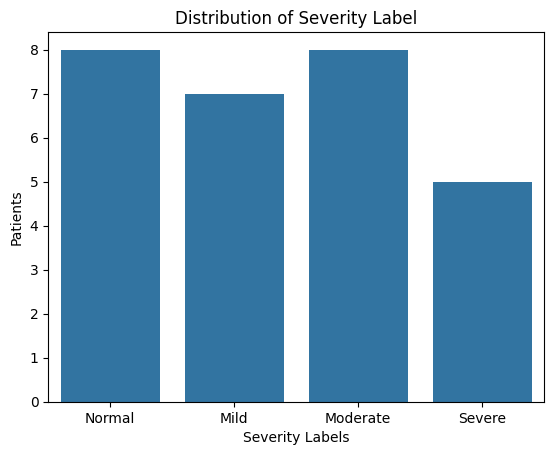

In [10]:
sns.countplot(
    data=integrated_df,
    x='Diagnosis Severity'
)

plt.title('Distribution of Severity Label')
plt.xlabel("Severity Labels")
plt.ylabel("Patients")
plt.show()

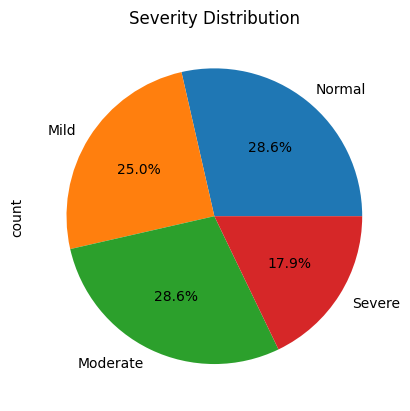

In [11]:
integrated_df['Diagnosis Severity'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%')
plt.title("Severity Distribution")
plt.show()

## Correlation Analysis

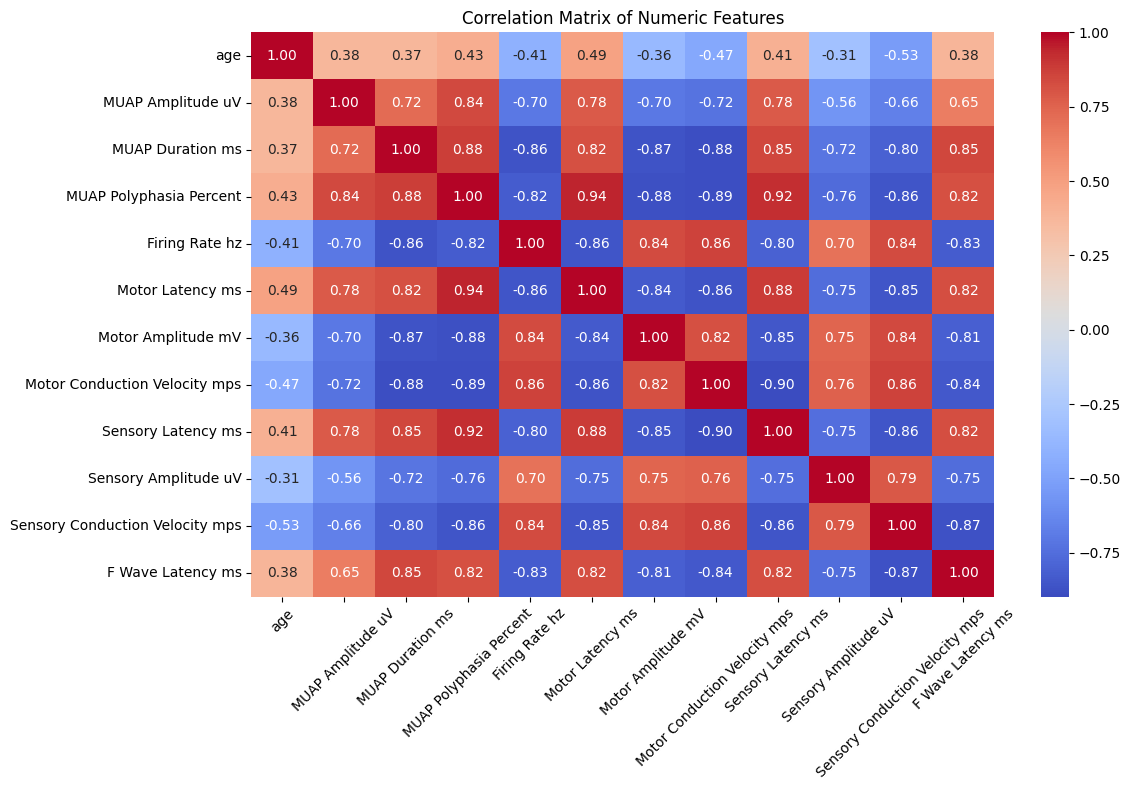

In [12]:
# Correlation matrix to detect collinear features

corr = integrated_df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

## Distribution of Each Feature

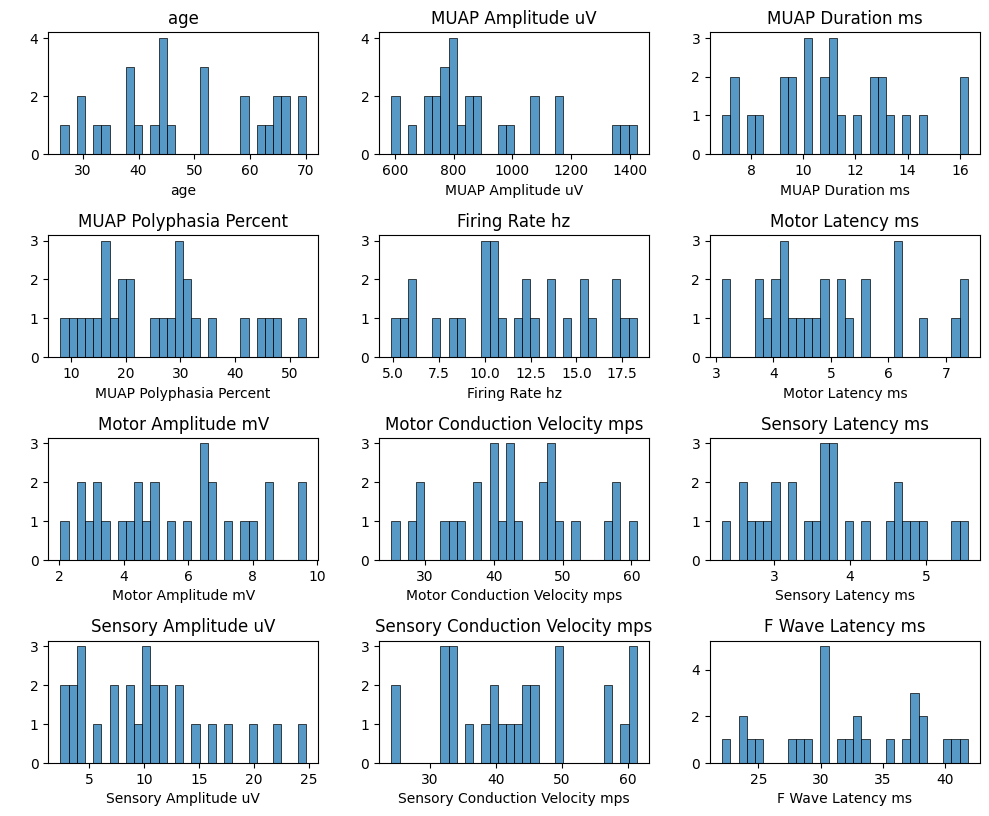

In [13]:
# Distribution of Numric Features

# number of charts per row
cols = 3

# round up the number of rows ; Ensures enough rows to display all features.
rows = math.ceil( len(numeric_features) / cols)

# Create Creates a new figure for all subplots ( witdh,height  )
plt.figure(figsize=(10, rows * 2))


for i, col in enumerate(numeric_features, 1):
    #Creates the i-th subplot in a grid of rows × cols.
    plt.subplot(rows, cols, i)

    # draws histogram + dropna() removes missing values before plottin + splits the data range into 30 buckets +  no density curve
    sns.histplot(integrated_df[col].dropna(), bins=30, kde=False)
    plt.title(f'{col}')
    plt.xlabel(col, fontsize=10)
    plt.ylabel(' ', fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_839/818755773.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=integrated_df, x=col, palette='Set2')
/tmp/ipykernel_839/818755773.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=integrated_df, x=col, palette='Set2')
/tmp/ipykernel_839/818755773.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=integrated_df, x=col, palette='Set2')
/tmp/ipykernel_839/818755773.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

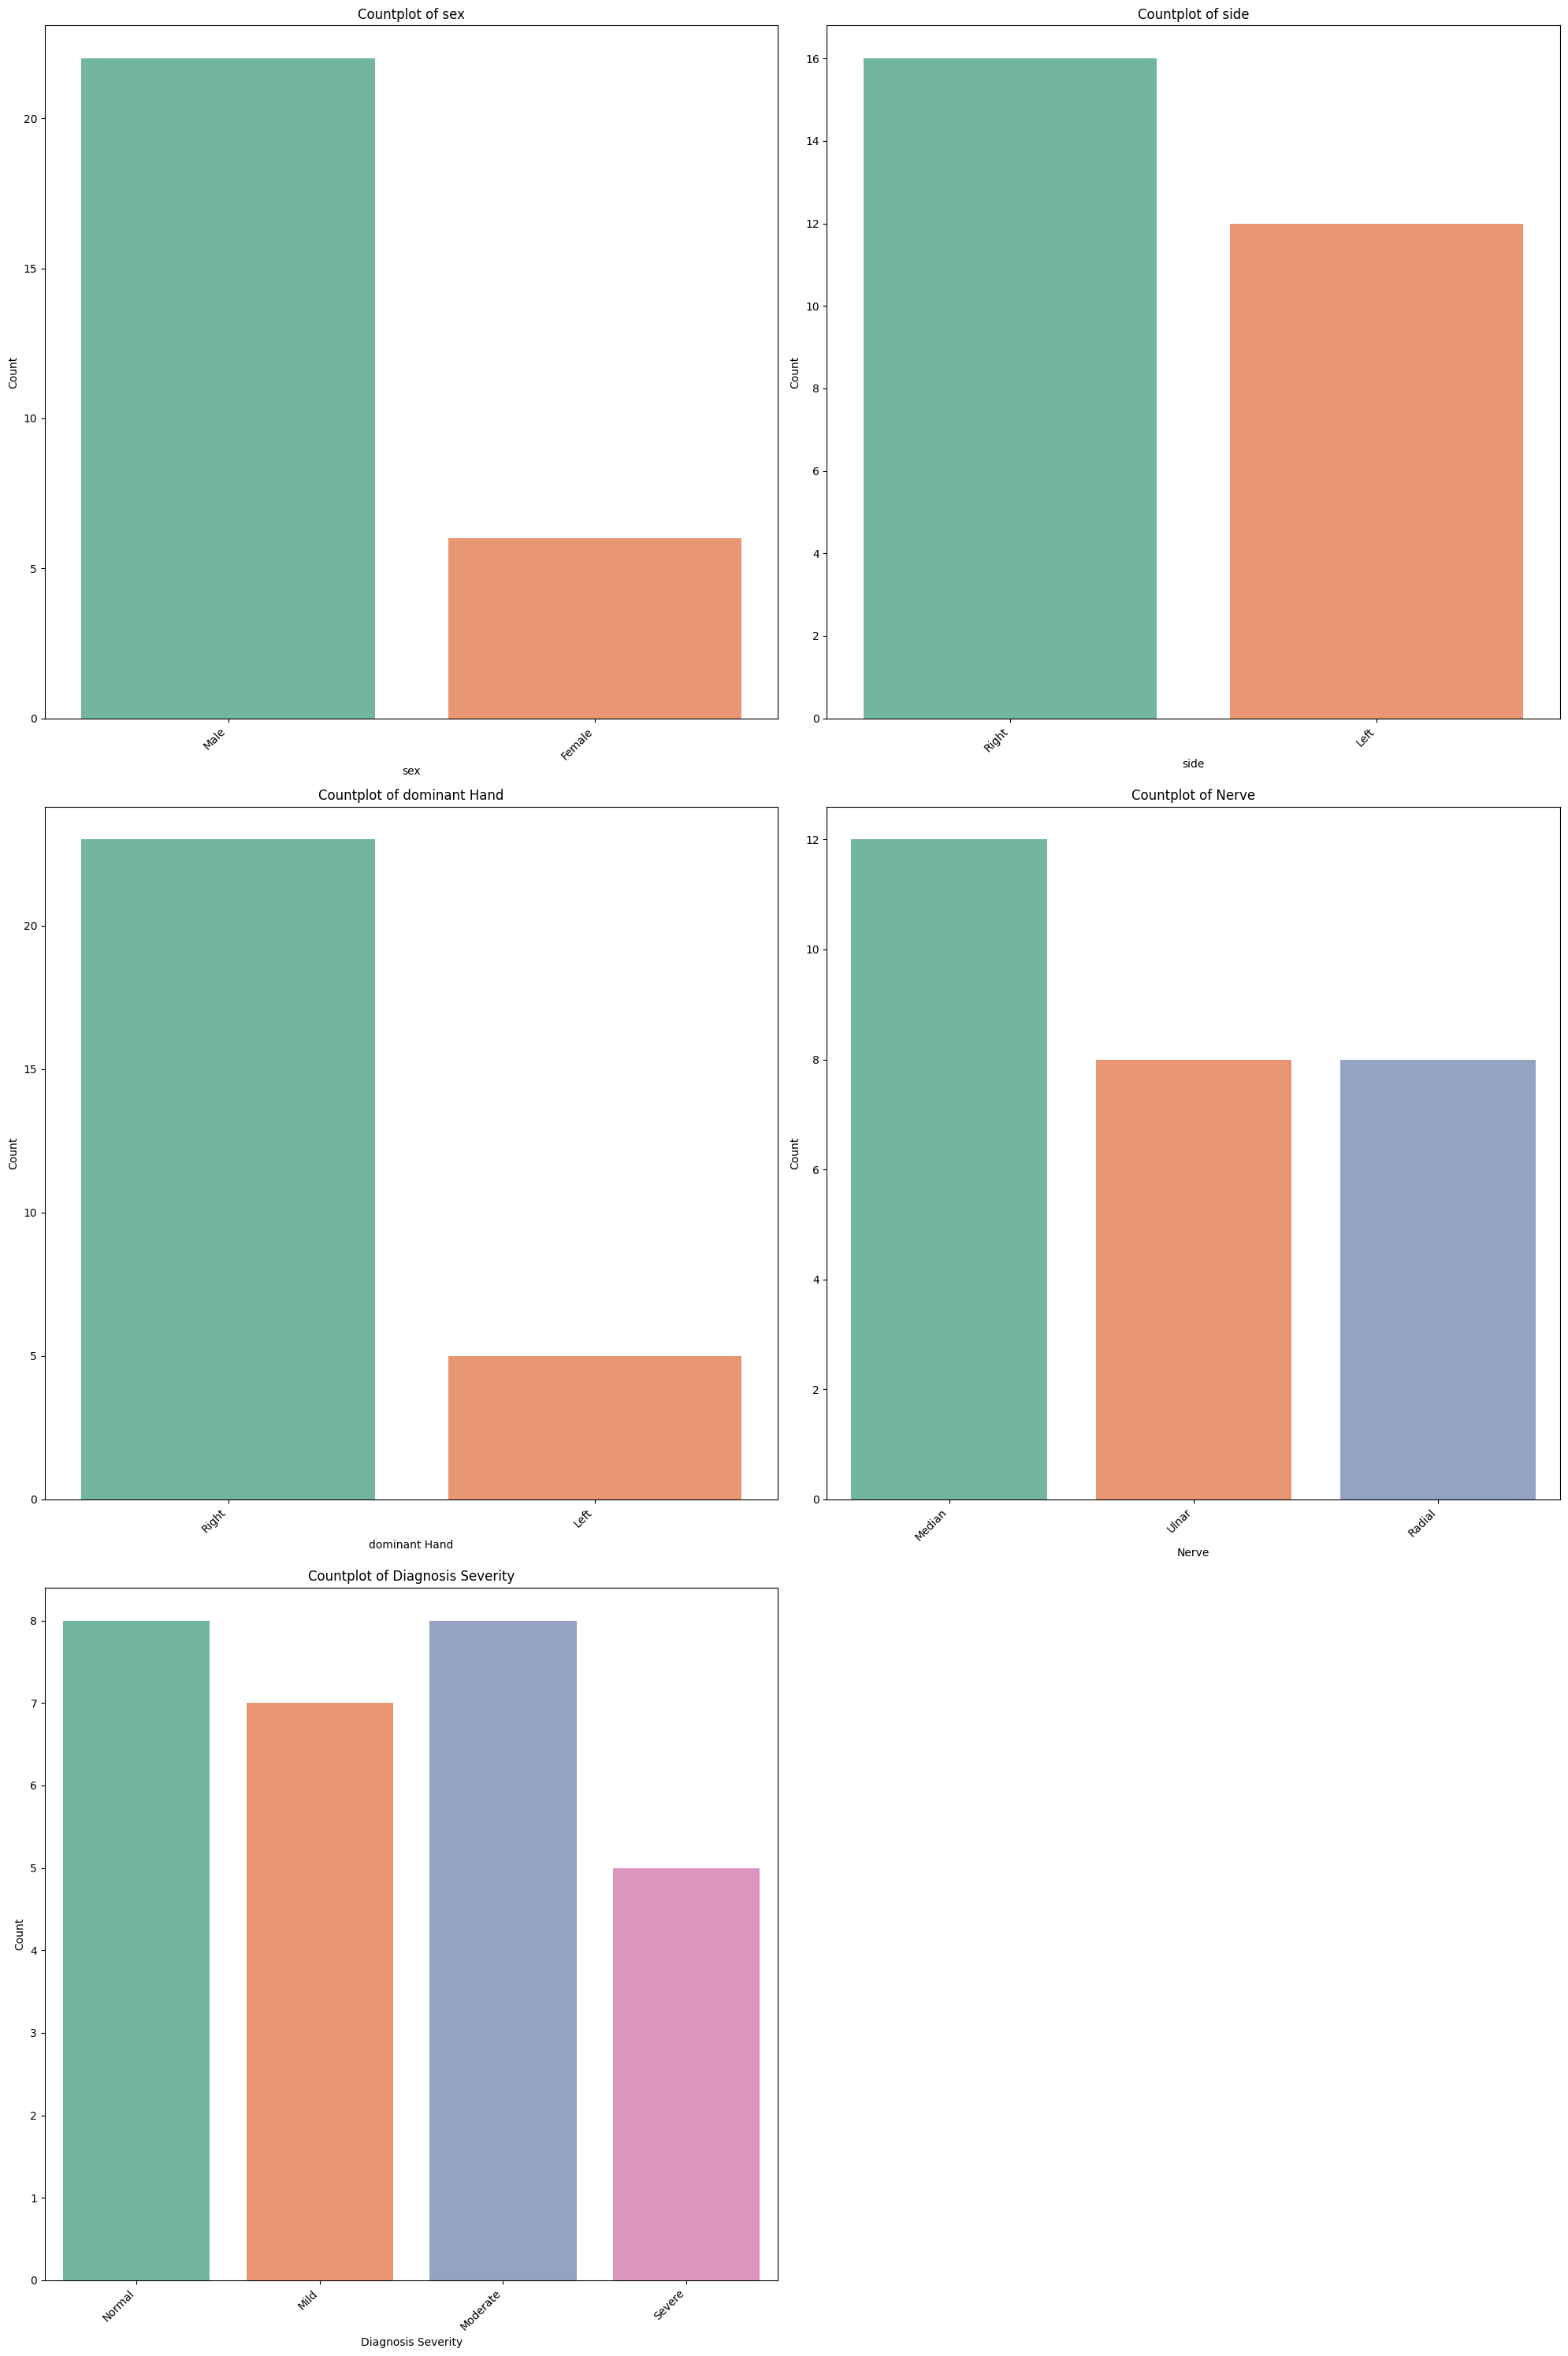

In [14]:
# Distribution of Catgorical Features

# Count Plot

# Select categorical columns
categorical_cols = integrated_df.select_dtypes(include=['object', 'category']).columns

# Number of categorical features
n_cat = len(categorical_cols)

# Layout
cols = 2   # number of plots per row
rows = math.ceil(n_cat / cols)

# Create figure
plt.figure(figsize=(20, rows * 10))

# Loop for subplots
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(data=integrated_df, x=col, palette='Set2')
    plt.title(f'Countplot of {col}', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

## Check Outliers

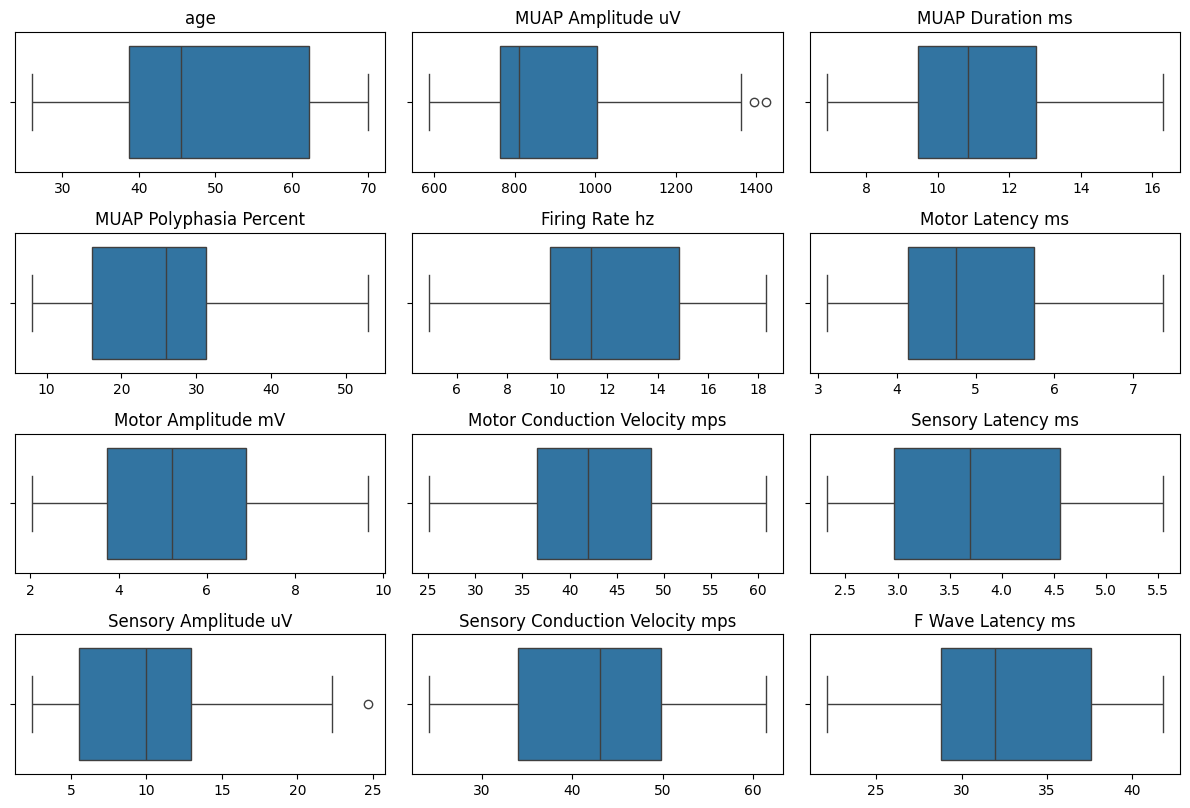

In [15]:
import math

n = len(numeric_features)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(12, rows * 2))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(rows, cols, i)

    sns.boxplot(x=integrated_df[col])

    plt.title(col)
    plt.xlabel("")

plt.tight_layout()
plt.show()

## Missing Values

In [16]:
print("Missing values per column:\n", integrated_df.isnull().sum()) #Nan None

Missing values per column:
 patient_id                         0
age                                0
sex                                0
side                               0
dominant Hand                      0
Nerve                              0
MUAP Amplitude uV                  0
MUAP Duration ms                   0
MUAP Polyphasia Percent            0
Firing Rate hz                     0
Motor Latency ms                   0
Motor Amplitude mV                 0
Motor Conduction Velocity mps      0
Sensory Latency ms                 0
Sensory Amplitude uV               0
Sensory Conduction Velocity mps    0
F Wave Latency ms                  0
Diagnosis Severity                 0
dtype: int64


## Duplicates Recoreds


In [17]:
dup_rows = integrated_df.duplicated().sum()
print("\nNumber of Fully Duplicated rows:", dup_rows)


Number of Fully Duplicated rows: 0


## Detecting Messy Format

In [18]:
# Detect Non-Numeric Characters Inside Numeric Columns

for col in integrated_df.select_dtypes(include='object'):
    # Check if column is supposed to be numeric
    try:
        integrated_df[col].astype(float)
        print(f"POSSIBLE WRONG FORMAT → {col}: contains numeric-like strings")
    except:
        pass


In [19]:
# Detect Mixed Formats

for col in integrated_df.select_dtypes(include='object'):
    print(f"\nUnique values in {col}:")
    print(integrated_df[col].unique())


Unique values in sex:
['Male' 'Female']

Unique values in side:
['Right' 'Left']

Unique values in dominant Hand:
['Right' 'Left']

Unique values in Nerve:
['Median' 'Ulnar' 'Radial']


In [20]:
# Detect Columns with Mixed Types

for col in integrated_df.columns:
    types = integrated_df[col].apply(type).value_counts()
    if len(types) > 1:
        print(f"Mixed types in {col}: {types}")

# Target Encoding

In [21]:
integrated_df['Diagnosis Severity'] = integrated_df['Diagnosis Severity'].map({
    'Normal': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3
})

# Train/Test Split

In [22]:
X = integrated_df.drop(columns=['Diagnosis Severity'])
y = integrated_df['Diagnosis Severity']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (19, 17)
X_test shape : (9, 17)
y_train shape: (19,)
y_test shape : (9,)


# Feature Selection

##Statistical Feature Selection

###1) Kruskal-Wallis Test For The Numeric Feature

In [23]:
# Target variable
y = y_train

# List of numeric features to test
numeric_cols = [
    'age',
    'MUAP Amplitude uV',
    'MUAP Duration ms',
    'MUAP Polyphasia Percent',
    'Firing Rate hz',
    'Motor Latency ms',
    'Motor Amplitude mV',
    'Motor Conduction Velocity mps',
    'Sensory Latency ms',
    'Sensory Amplitude uV',
    'Sensory Conduction Velocity mps',
    'F Wave Latency ms'
]

# Store Kruskal test results
kruskal_results = []

# Loop through each numeric feature
for feature in numeric_cols:

    # Skip feature if not found in training data
    if feature not in X_train.columns:
        continue

    # Split feature values into groups based on target classes
    groups = [
        X_train[y == cls][feature].dropna()
        for cls in y.unique()
    ]

    # Skip if any group has insufficient samples
    if any(len(g) < 2 for g in groups):
        continue

    # Apply Kruskal-Wallis test
    stat, p = kruskal(*groups)

    # Store results
    kruskal_results.append({
        "Feature": feature,
        "Kruskal Statistic": stat,
        "p-value": p
    })

# Convert results to DataFrame
results_df = pd.DataFrame(kruskal_results)

# Sort features by p-value (ascending)
results_df = results_df.sort_values("p-value").reset_index(drop=True)

# Add significance flag based on threshold
results_df["Significant (p≤0.05)"] = results_df["p-value"].apply(
    lambda x: "Yes" if x <= 0.05 else "No"
)

# Display results
results_df

,Feature,Kruskal Statistic,p-value,Significant (p≤0.05)
0,Motor Conduction Velocity mps,16.752632,0.000795,Yes
1,Motor Latency ms,16.463916,0.000911,Yes
2,Sensory Latency ms,16.343810,0.000964,Yes
3,MUAP Polyphasia Percent,15.960950,0.001155,Yes
4,Sensory Conduction Velocity mps,15.565263,0.001392,Yes
5,Motor Amplitude mV,15.157895,0.001687,Yes
6,Firing Rate hz,14.662302,0.002129,Yes
7,MUAP Duration ms,14.062105,0.002822,Yes
8,F Wave Latency ms,13.722105,0.003309,Yes
9,Sensory Amplitude uV,13.578947,0.003538,Yes


###2) Chi-Square Test For The Categorical Features

In [24]:
# Categorical features to test
categorical_features = [
    'sex',
    'side',
    'dominant Hand',
    'Nerve'
]

# Store Chi-Square results
chi_results = []

# Loop through each categorical feature
for feature in categorical_features:

    # Skip feature if not found in training data
    if feature not in X_train.columns:
        continue

    # Create contingency table using TRAIN only
    table = pd.crosstab(X_train[feature], y)

    # Skip if table is empty or has only one category
    if table.shape[0] < 2 or table.shape[1] < 2:
        continue

    # Apply Chi-Square test
    chi2, p, dof, expected = chi2_contingency(table)

    # Store results
    chi_results.append({
        "Feature": feature,
        "Chi2 Statistic": chi2,
        "p-value": p,
        "Significant (p≤0.05)": "Yes" if p <= 0.05 else "No"
    })

# Convert to DataFrame
chi_df = pd.DataFrame(chi_results)

# Sort by p-value (ascending)
chi_df = chi_df.sort_values(by="p-value").reset_index(drop=True)

# Display results
print("Chi-Square Test Results (Train Only):")
chi_df

Chi-Square Test Results (Train Only):


,Feature,Chi2 Statistic,p-value,Significant (p≤0.05)
0,side,2.955556,0.398529,No
1,Nerve,5.404444,0.493080,No
2,sex,1.952778,0.582265,No
3,dominant Hand,0.699306,0.873367,No


## Fisher Score

In [25]:
# Select only numeric features from X_train (no redefinition of X_train/y_train)
X_train_numeric = X_train[numeric_cols]

# Apply Fisher Score (ANOVA F-test)
f_scores, p_values = f_classif(X_train_numeric, y_train)

# Create results DataFrame
fisher_df = pd.DataFrame({
    'Feature': X_train_numeric.columns,
    'Fisher Score': f_scores,
    'p-value': p_values
})

# Sort by Fisher Score (descending)
fisher_df = fisher_df.sort_values(by='Fisher Score', ascending=False).reset_index(drop=True)

# Add significance flag
fisher_df['Significant (p≤0.05)'] = fisher_df['p-value'].apply(
    lambda x: 'Yes' if x <= 0.05 else 'No'
)

# Display
fisher_df

,Feature,Fisher Score,p-value,Significant (p≤0.05)
0,MUAP Polyphasia Percent,55.385773,2.396448e-08,Yes
1,Motor Conduction Velocity mps,51.424187,3.975412e-08,Yes
2,Motor Latency ms,40.819186,1.875893e-07,Yes
3,Firing Rate hz,40.571158,1.953268e-07,Yes
4,Sensory Latency ms,35.850277,4.408245e-07,Yes
5,Motor Amplitude mV,28.140836,2.085892e-06,Yes
6,Sensory Conduction Velocity mps,25.530495,3.833897e-06,Yes
7,MUAP Duration ms,18.163741,2.958483e-05,Yes
8,MUAP Amplitude uV,17.431794,3.749535e-05,Yes
9,F Wave Latency ms,14.764304,9.528684e-05,Yes


## Drop anything but Selected Features

In [26]:

selected_features  = [
    'MUAP Amplitude uV',
    'MUAP Duration ms',
    'MUAP Polyphasia Percent',
    'Firing Rate hz',
    'Motor Latency ms',
    'Motor Amplitude mV',
    'Motor Conduction Velocity mps',
    'Sensory Latency ms',
    'Sensory Amplitude uV',
    'Sensory Conduction Velocity mps',
    'F Wave Latency ms'\
]

# New DF
X_train_selected = X_train[selected_features].copy()
X_test_selected  = X_test[selected_features].copy()

#incpect/Mini EDA (orignal Data)

In [27]:
print("=== SHAPES ===")
print("=== SHAPES (SELECTED) ===")
print("X_train_selected:", X_train_selected.shape)
print("X_test_selected :", X_test_selected.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\n=== FEATURES USED ===")
print(list(X_train_selected.columns))

# Class distribution
print("\n=== CLASS DISTRIBUTION (TRAIN) ===")
train_dist = y_train.value_counts().sort_index()
print(train_dist)

print("\n=== CLASS DISTRIBUTION (TEST) ===")
test_dist = y_test.value_counts().sort_index()
print(test_dist)



print("\n=== CHECKS ===")

# Same features in train/test
print("Same columns:",
      list(X_train_selected.columns) == list(X_test_selected.columns))

# Missing values
print("Missing in X_train_selected:",
      X_train_selected.isnull().sum().sum())

print("Missing in X_test_selected :",
      X_test_selected.isnull().sum().sum())

# Index alignment
print("Index aligned (train):",
      (X_train_selected.index == y_train.index).all())

print("Index aligned (test):",
      (X_test_selected.index == y_test.index).all())

=== SHAPES ===
=== SHAPES (SELECTED) ===
X_train_selected: (19, 11)
X_test_selected : (9, 11)
y_train shape: (19,)
y_test shape : (9,)

=== FEATURES USED ===
['MUAP Amplitude uV', 'MUAP Duration ms', 'MUAP Polyphasia Percent', 'Firing Rate hz', 'Motor Latency ms', 'Motor Amplitude mV', 'Motor Conduction Velocity mps', 'Sensory Latency ms', 'Sensory Amplitude uV', 'Sensory Conduction Velocity mps', 'F Wave Latency ms']

=== CLASS DISTRIBUTION (TRAIN) ===
Diagnosis Severity
0    5
1    5
2    6
3    3
Name: count, dtype: int64

=== CLASS DISTRIBUTION (TEST) ===
Diagnosis Severity
0    3
1    2
2    2
3    2
Name: count, dtype: int64

=== CHECKS ===
Same columns: True
Missing in X_train_selected: 0
Missing in X_test_selected : 0
Index aligned (train): True
Index aligned (test): True


##Correlation Matrix before Data Augmentation

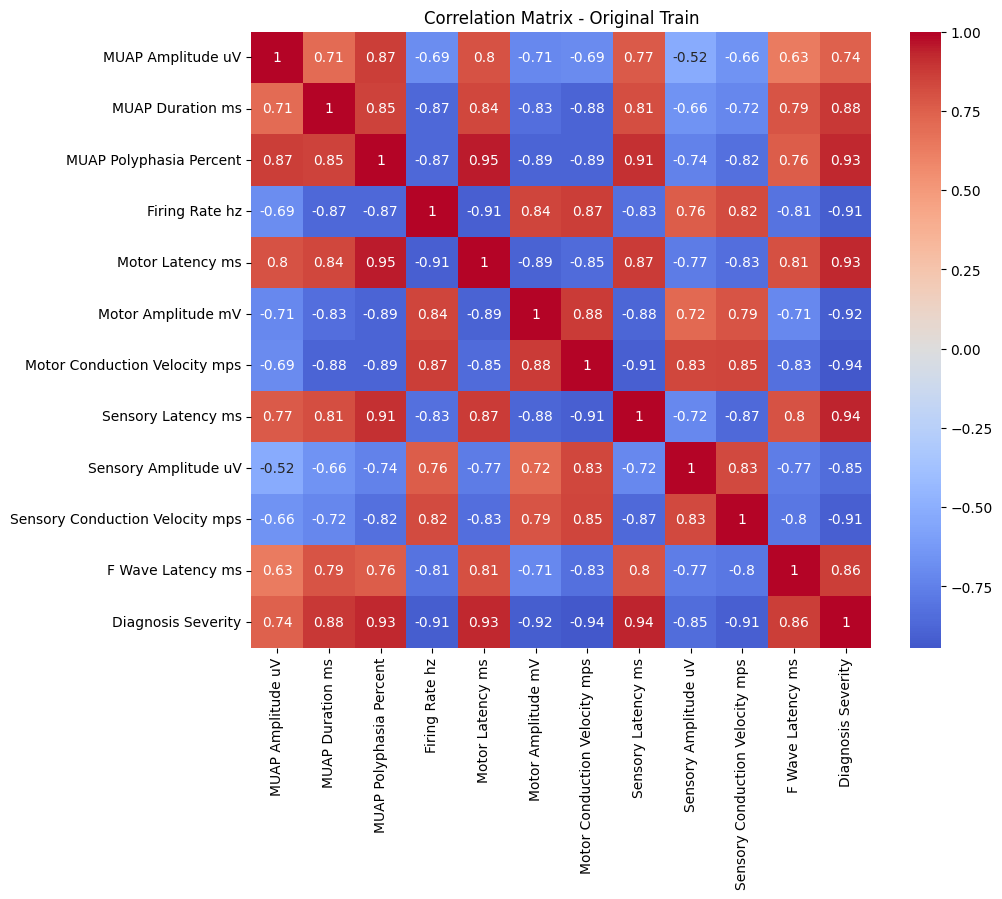

In [28]:
train_df = X_train_selected.copy()
train_df['Diagnosis Severity'] = y_train

corr_matrix = train_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix - Original Train")
plt.show()

#Gaussian

## Scaling

In [29]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_selected),
    columns=X_train_selected.columns,
    index=X_train_selected.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_selected),
    columns=X_test_selected.columns,
    index=X_test_selected.index
)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

X_train_scaled: (19, 11)
X_test_scaled : (9, 11)


# Gaussian Copula Synthetic Data Function

In [30]:
def generate_gaussian_copula_synthetic(
    X_train_scaled,
    y_train,
    target_per_class=15,
    random_state=42
):
    np.random.seed(random_state)

    X_syn_list = []
    y_syn_list = []

    for cls in sorted(y_train.unique()):

        X_cls = X_train_scaled[y_train == cls].copy()

        if len(X_cls) < 2:
            continue

        n_to_generate = max(0, target_per_class - len(X_cls))

        if n_to_generate == 0:
            continue

        U = pd.DataFrame(index=X_cls.index)

        for col in X_cls.columns:
            ranks = rankdata(X_cls[col], method="average")
            U[col] = ranks / (len(X_cls) + 1)

        Z = pd.DataFrame(
            norm.ppf(U),
            columns=X_cls.columns,
            index=X_cls.index
        )

        corr_matrix = Z.corr().values
        corr_matrix = np.nan_to_num(corr_matrix, nan=0.0)

        corr_matrix = corr_matrix + np.eye(corr_matrix.shape[0]) * 1e-6

        try:
            Z_new = np.random.multivariate_normal(
                mean=np.zeros(X_cls.shape[1]),
                cov=corr_matrix,
                size=n_to_generate
            )
        except np.linalg.LinAlgError:
            corr_matrix = corr_matrix + np.eye(corr_matrix.shape[0]) * 1e-4
            Z_new = np.random.multivariate_normal(
                mean=np.zeros(X_cls.shape[1]),
                cov=corr_matrix,
                size=n_to_generate
            )

        U_new = norm.cdf(Z_new)

        X_new = pd.DataFrame(columns=X_cls.columns)

        for i, col in enumerate(X_cls.columns):
            X_new[col] = np.quantile(X_cls[col], U_new[:, i])

        X_syn_list.append(X_new)
        y_syn_list.extend([cls] * n_to_generate)

    if len(X_syn_list) == 0:
        X_syn = pd.DataFrame(columns=X_train_scaled.columns)
        y_syn = pd.Series(dtype=int, name="Diagnosis Severity")
        return X_syn, y_syn

    X_syn = pd.concat(X_syn_list, axis=0).reset_index(drop=True)
    y_syn = pd.Series(y_syn_list, name="Diagnosis Severity")

    return X_syn, y_syn

## Synthetic Data Evaluation Functions

In [31]:
def distribution_similarity(X_real, X_syn):

    ks_scores = []
    wasserstein_scores = []

    for col in X_real.columns:

        real = X_real[col]
        syn = X_syn[col]

        ks_stat, _ = ks_2samp(real, syn)
        wass = wasserstein_distance(real, syn)

        ks_scores.append(ks_stat)
        wasserstein_scores.append(wass)

    return {
        "KS_Mean": np.mean(ks_scores),
        "Wasserstein_Mean": np.mean(wasserstein_scores)
    }


def correlation_difference(X_real, X_syn):

    corr_real = X_real.corr(method="spearman")
    corr_syn = X_syn.corr(method="spearman")

    corr_diff_matrix = (corr_real - corr_syn).abs()

    corr_diff_mean = corr_diff_matrix.values[
        np.triu_indices_from(corr_diff_matrix, k=1)
    ].mean()

    return corr_diff_mean


def mutual_information_difference(X_real, y_real, X_syn, y_syn):

    mi_real = mutual_info_classif(
        X_real,
        y_real,
        random_state=42
    )

    mi_syn = mutual_info_classif(
        X_syn,
        y_syn,
        random_state=42
    )

    mi_diff = np.mean(np.abs(mi_real - mi_syn))

    return mi_diff


def nearest_neighbor_distance(X_real, X_syn):

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(X_real)

    distances, _ = nn.kneighbors(X_syn)

    return {
        "NN_Distance_Mean": distances.mean(),
        "NN_Distance_Min": distances.min()
    }


def jensen_shannon_distance(X_real, X_syn):

    js_list = []

    for col in X_real.columns:

        real = X_real[col]
        syn = X_syn[col]

        min_val = min(real.min(), syn.min())
        max_val = max(real.max(), syn.max())

        hist_real, bins = np.histogram(
            real,
            bins=10,
            range=(min_val, max_val),
            density=True
        )

        hist_syn, _ = np.histogram(
            syn,
            bins=bins,
            density=True
        )

        hist_real += 1e-8
        hist_syn += 1e-8

        js = jensenshannon(hist_real, hist_syn)
        js_list.append(js)

    return np.mean(js_list)

## Generateing Synthetic Data

In [32]:
target_per_class = 15

X_gc_syn, y_gc_syn = generate_gaussian_copula_synthetic(
    X_train_scaled=X_train_scaled,
    y_train=y_train,
    target_per_class=target_per_class,
    random_state=42
)
X_gc_syn = X_gc_syn

print("Synthetic X shape:", X_gc_syn.shape)
print("\nSynthetic class distribution:")
print(y_gc_syn.value_counts().sort_index())

display(X_gc_syn.head())

Synthetic X shape: (41, 11)

Synthetic class distribution:
Diagnosis Severity
0    10
1    10
2     9
3    12
Name: count, dtype: int64


,MUAP Amplitude uV,MUAP Duration ms,MUAP Polyphasia Percent,Firing Rate hz,Motor Latency ms,Motor Amplitude mV,Motor Conduction Velocity mps,Sensory Latency ms,Sensory Amplitude uV,Sensory Conduction Velocity mps,F Wave Latency ms
0,-0.508189,-1.677744,-1.084985,1.173410,-1.493223,1.524730,1.651774,-1.207218,0.885032,1.561811,-1.862001
1,-0.490334,-0.715795,-0.810763,1.350156,-0.849530,1.530926,1.233228,-1.412030,0.999951,0.859029,-0.420009
2,-0.261545,-0.878525,-0.868050,1.693182,-1.273567,1.600134,1.002186,-1.089858,0.696530,1.075828,-1.118895
3,-0.526418,-0.742397,-0.784497,1.054333,-0.736044,1.196137,1.030163,-1.499278,0.607986,1.832053,-0.460781
4,-0.437803,-0.767588,-0.700141,1.179005,-0.758875,1.061144,0.861779,-1.162689,0.502689,1.871111,-1.378960


# Evaluate Gaussian Copula Synthetic Data

In [33]:
dist_results = distribution_similarity(
    X_train_scaled,
    X_gc_syn
)

corr_diff = correlation_difference(
    X_train_scaled,
    X_gc_syn
)

mi_diff = mutual_information_difference(
    X_train_scaled,
    y_train,
    X_gc_syn,
    y_gc_syn
)

nn_results = nearest_neighbor_distance(
    X_train_scaled,
    X_gc_syn
)

js_score = jensen_shannon_distance(
    X_train_scaled,
    X_gc_syn
)

gc_summary_df = pd.DataFrame([{
    "Method": "Gaussian Copula",
    "Target_Per_Class": target_per_class,
    "KS_Mean": dist_results["KS_Mean"],
    "Wasserstein_Mean": dist_results["Wasserstein_Mean"],
    "JS_Distance": js_score,
    "Corr_Diff": corr_diff,
    "MI_Diff": mi_diff,
    "NN_Distance_Mean": nn_results["NN_Distance_Mean"],
    "NN_Distance_Min": nn_results["NN_Distance_Min"]
}])

display(gc_summary_df)

,Method,Target_Per_Class,KS_Mean,Wasserstein_Mean,JS_Distance,Corr_Diff,MI_Diff,NN_Distance_Mean,NN_Distance_Min
0,Gaussian Copula,15,0.172482,0.229082,0.245019,0.069341,0.398062,0.861608,0.325984


## Apply Clinical Constraints

In [34]:
X_gc_syn_original = pd.DataFrame(
    scaler.inverse_transform(X_gc_syn),
    columns=X_train_scaled.columns
)

X_gc_syn_original = X_gc_syn_original.clip(lower=0)

X_gc_syn_original["MUAP Polyphasia Percent"] = (
    X_gc_syn_original["MUAP Polyphasia Percent"].clip(0, 100)
)

X_gc_syn_original = X_gc_syn_original.round(2)

display(X_gc_syn_original.head(10))

,MUAP Amplitude uV,MUAP Duration ms,MUAP Polyphasia Percent,Firing Rate hz,Motor Latency ms,Motor Amplitude mV,Motor Conduction Velocity mps,Sensory Latency ms,Sensory Amplitude uV,Sensory Conduction Velocity mps,F Wave Latency ms
0,778.24,7.60,14.01,15.68,3.11,8.25,56.96,2.71,15.71,58.10,23.53
1,782.73,9.67,17.20,16.33,3.90,8.27,53.30,2.53,16.39,51.29,30.59
2,840.17,9.32,16.54,17.60,3.38,8.40,51.28,2.81,14.59,53.39,27.16
3,773.67,9.61,17.51,15.24,4.04,7.60,51.52,2.46,14.06,60.71,30.39
4,795.92,9.56,18.49,15.70,4.01,7.33,50.05,2.75,13.44,61.09,25.89
5,804.17,7.81,13.95,17.53,3.11,8.48,56.86,2.73,15.78,49.83,27.14
6,703.69,9.37,15.53,15.31,3.80,7.46,57.54,2.63,21.14,56.61,29.04
7,783.89,9.58,16.73,16.16,3.81,8.41,52.22,2.48,13.63,55.69,30.53
8,773.80,9.30,16.40,15.34,3.81,7.53,54.42,2.64,15.31,60.69,26.27
9,840.13,9.44,16.99,17.59,3.73,8.27,50.98,2.85,15.69,54.45,27.46


## Save Synthetic Data

In [35]:
synthetic_gc_df = X_gc_syn_original.copy()
synthetic_gc_df["Diagnosis Severity"] = y_gc_syn.reset_index(drop=True)

display(synthetic_gc_df.head(10))

synthetic_gc_df.to_excel(
    "gaussian_copula_synthetic_data_constrained.xlsx",
    index=False
)

print("File saved: gaussian_copula_synthetic_data_constrained.xlsx")

,MUAP Amplitude uV,MUAP Duration ms,MUAP Polyphasia Percent,Firing Rate hz,Motor Latency ms,Motor Amplitude mV,Motor Conduction Velocity mps,Sensory Latency ms,Sensory Amplitude uV,Sensory Conduction Velocity mps,F Wave Latency ms,Diagnosis Severity
0,778.24,7.60,14.01,15.68,3.11,8.25,56.96,2.71,15.71,58.10,23.53,0
1,782.73,9.67,17.20,16.33,3.90,8.27,53.30,2.53,16.39,51.29,30.59,0
2,840.17,9.32,16.54,17.60,3.38,8.40,51.28,2.81,14.59,53.39,27.16,0
3,773.67,9.61,17.51,15.24,4.04,7.60,51.52,2.46,14.06,60.71,30.39,0
4,795.92,9.56,18.49,15.70,4.01,7.33,50.05,2.75,13.44,61.09,25.89,0
5,804.17,7.81,13.95,17.53,3.11,8.48,56.86,2.73,15.78,49.83,27.14,0
6,703.69,9.37,15.53,15.31,3.80,7.46,57.54,2.63,21.14,56.61,29.04,0
7,783.89,9.58,16.73,16.16,3.81,8.41,52.22,2.48,13.63,55.69,30.53,0
8,773.80,9.30,16.40,15.34,3.81,7.53,54.42,2.64,15.31,60.69,26.27,0
9,840.13,9.44,16.99,17.59,3.73,8.27,50.98,2.85,15.69,54.45,27.46,0


File saved: gaussian_copula_synthetic_data_constrained.xlsx


## Convert Synthetic Data Back to Scaled Format

In [36]:
X_gc_syn_scaled = pd.DataFrame(
    scaler.transform(X_gc_syn_original),
    columns=X_train_scaled.columns
)

display(X_gc_syn_scaled.head())

,MUAP Amplitude uV,MUAP Duration ms,MUAP Polyphasia Percent,Firing Rate hz,Motor Latency ms,Motor Amplitude mV,Motor Conduction Velocity mps,Sensory Latency ms,Sensory Amplitude uV,Sensory Conduction Velocity mps,F Wave Latency ms
0,-0.508204,-1.676068,-1.085146,1.174517,-1.493223,1.522672,1.651896,-1.209042,0.885780,1.562087,-1.861417
1,-0.490322,-0.716538,-0.810885,1.350296,-0.848793,1.532742,1.233477,-1.414555,1.000349,0.858822,-0.419203
2,-0.261554,-0.878777,-0.867628,1.693741,-1.272975,1.598196,1.002546,-1.094868,0.697079,1.075688,-1.119882
3,-0.526405,-0.744350,-0.784232,1.055528,-0.734590,1.195401,1.029983,-1.494476,0.607782,1.831621,-0.460059
4,-0.437790,-0.767527,-0.699976,1.179926,-0.759062,1.059457,0.861930,-1.163372,0.503322,1.870863,-1.379317


## Combine Real and Synthetic Training Data

In [37]:
X_train_augmented = pd.concat(
    [
        X_train_scaled.reset_index(drop=True),
        X_gc_syn_scaled.reset_index(drop=True)
    ],
    axis=0
)

y_train_augmented = pd.concat(
    [
        y_train.reset_index(drop=True),
        y_gc_syn.reset_index(drop=True)
    ],
    axis=0
)

print("Original training shape:", X_train_scaled.shape)
print("Augmented training shape:", X_train_augmented.shape)

print("\nOriginal class distribution:")
print(y_train.value_counts().sort_index())

print("\nAugmented class distribution:")
print(y_train_augmented.value_counts().sort_index())

Original training shape: (19, 11)
Augmented training shape: (60, 11)

Original class distribution:
Diagnosis Severity
0    5
1    5
2    6
3    3
Name: count, dtype: int64

Augmented class distribution:
Diagnosis Severity
0    15
1    15
2    15
3    15
Name: count, dtype: int64


# Correlation Matrix After Augmentation

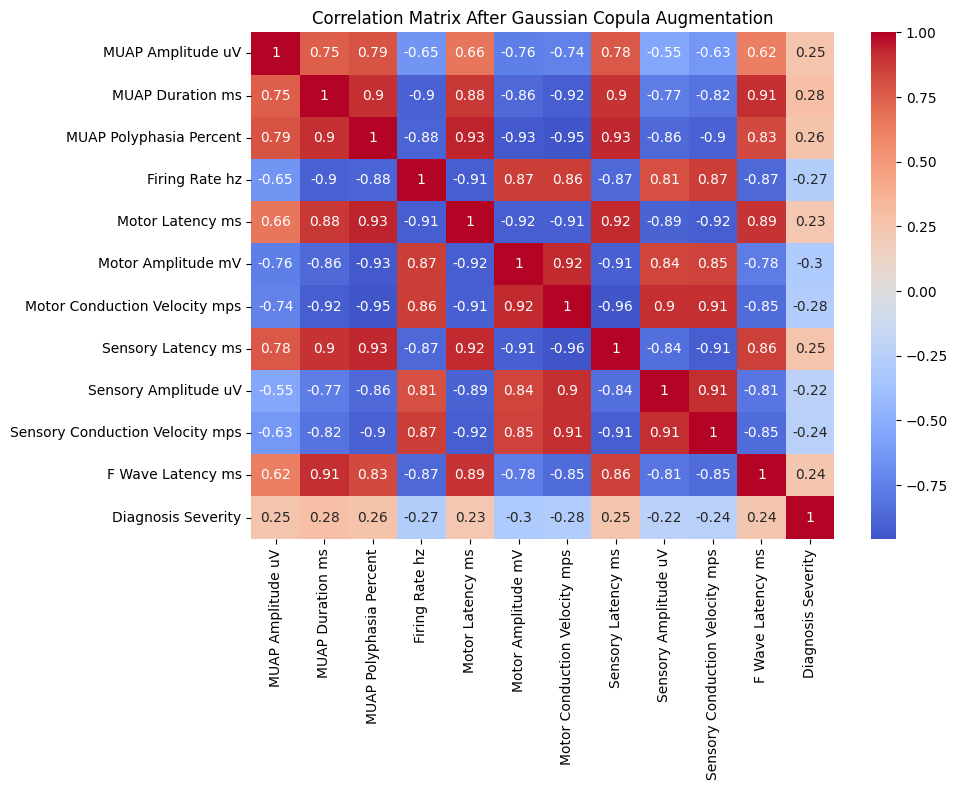

In [38]:
augmented_corr_df = X_train_augmented.copy()
augmented_corr_df["Diagnosis Severity"] = y_train_augmented.reset_index(drop=True)

corr_augmented = augmented_corr_df.corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_augmented,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix After Gaussian Copula Augmentation")
plt.tight_layout()
plt.show()

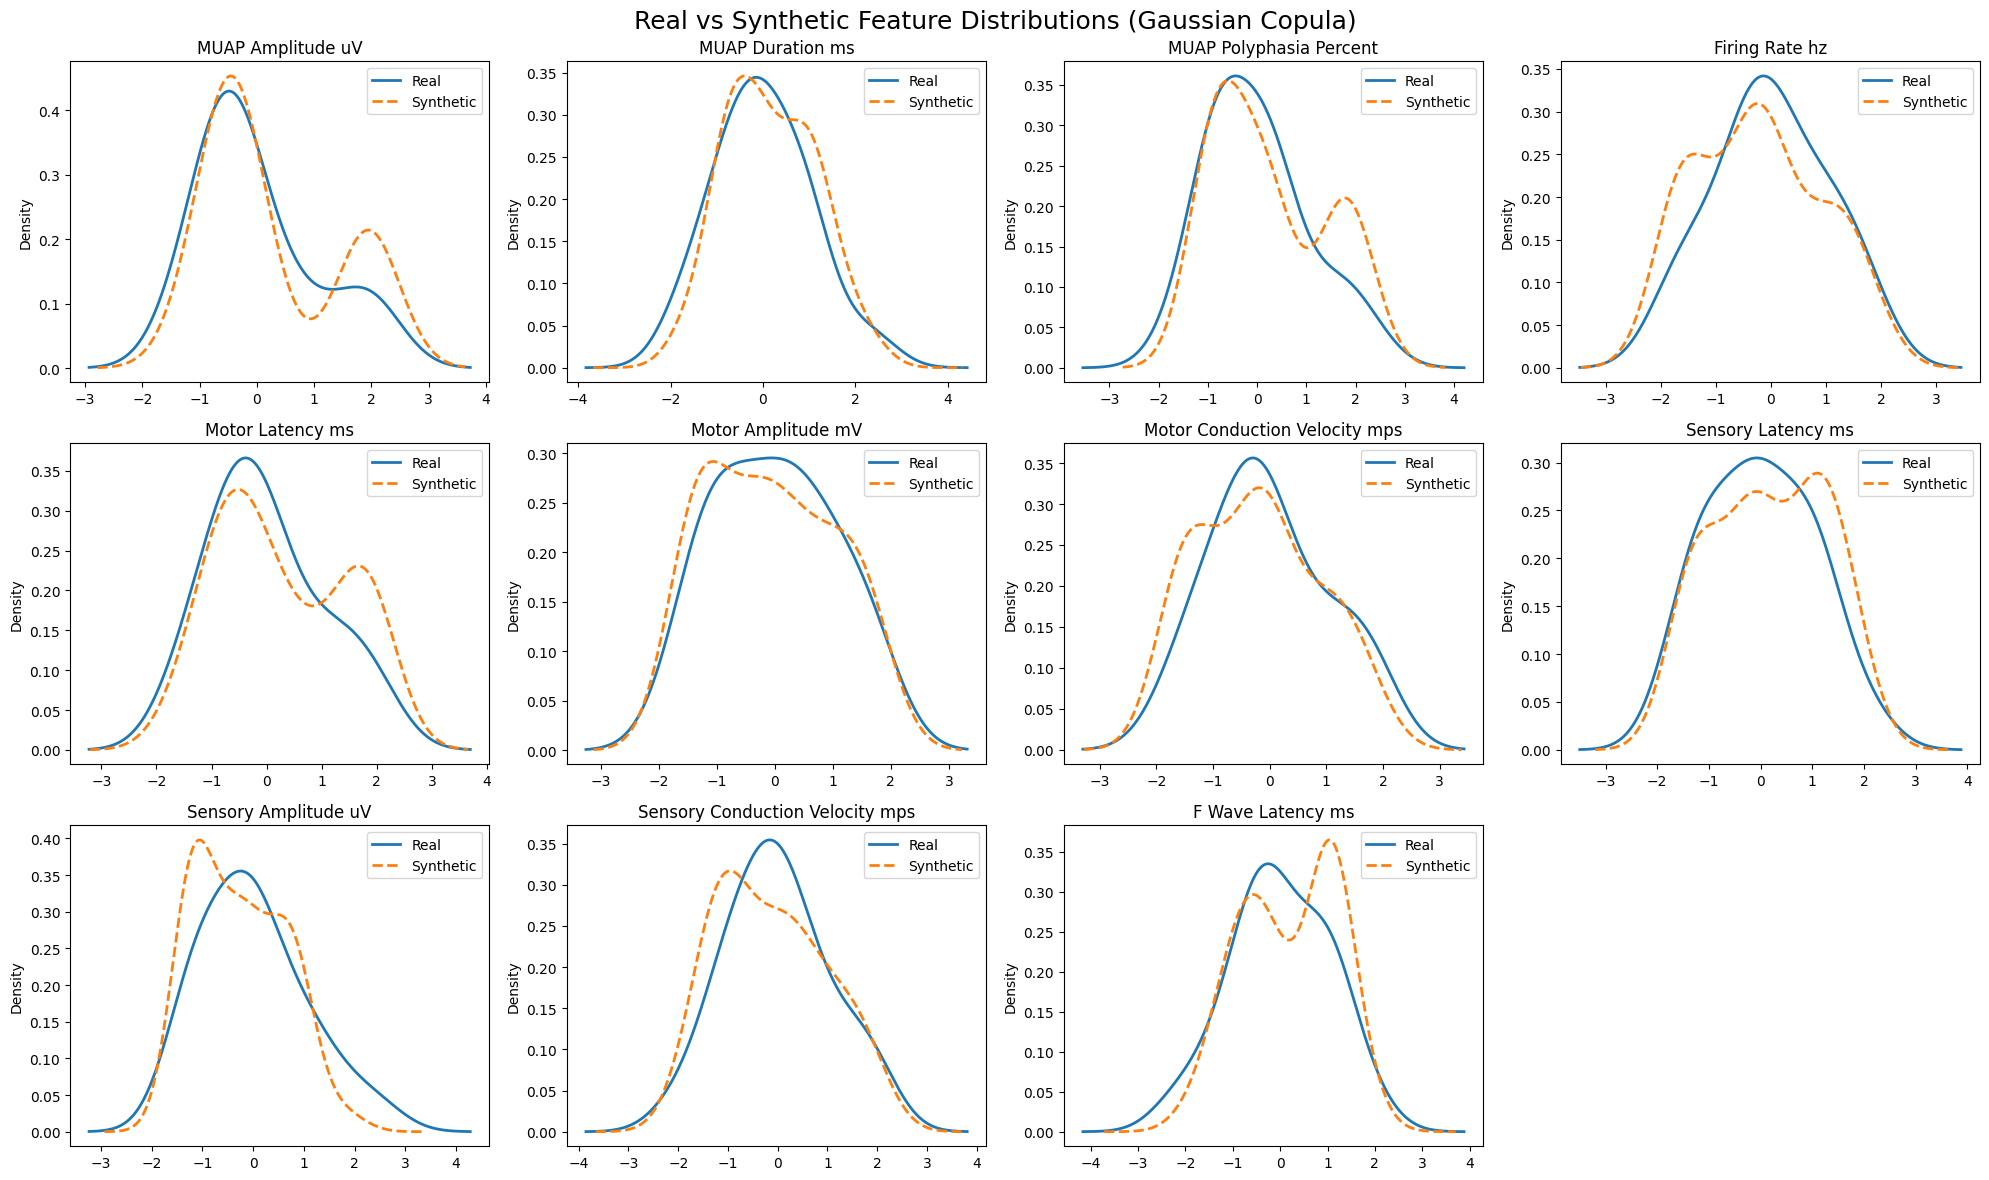

In [39]:
n_features = len(X_train_scaled.columns)

cols = 4
rows = math.ceil(n_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

fig.suptitle("Real vs Synthetic Feature Distributions (Gaussian Copula)", fontsize=18)

for i, col in enumerate(X_train_scaled.columns):

    ax = axes[i]

    # Real distribution
    X_train_scaled[col].plot(
        kind="kde",
        ax=ax,
        label="Real",
        linewidth=2
    )

    # Synthetic distribution
    X_gc_syn_scaled[col].plot(
        kind="kde",
        ax=ax,
        label="Synthetic",
        linestyle="--",
        linewidth=2
    )

    ax.set_title(col)
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

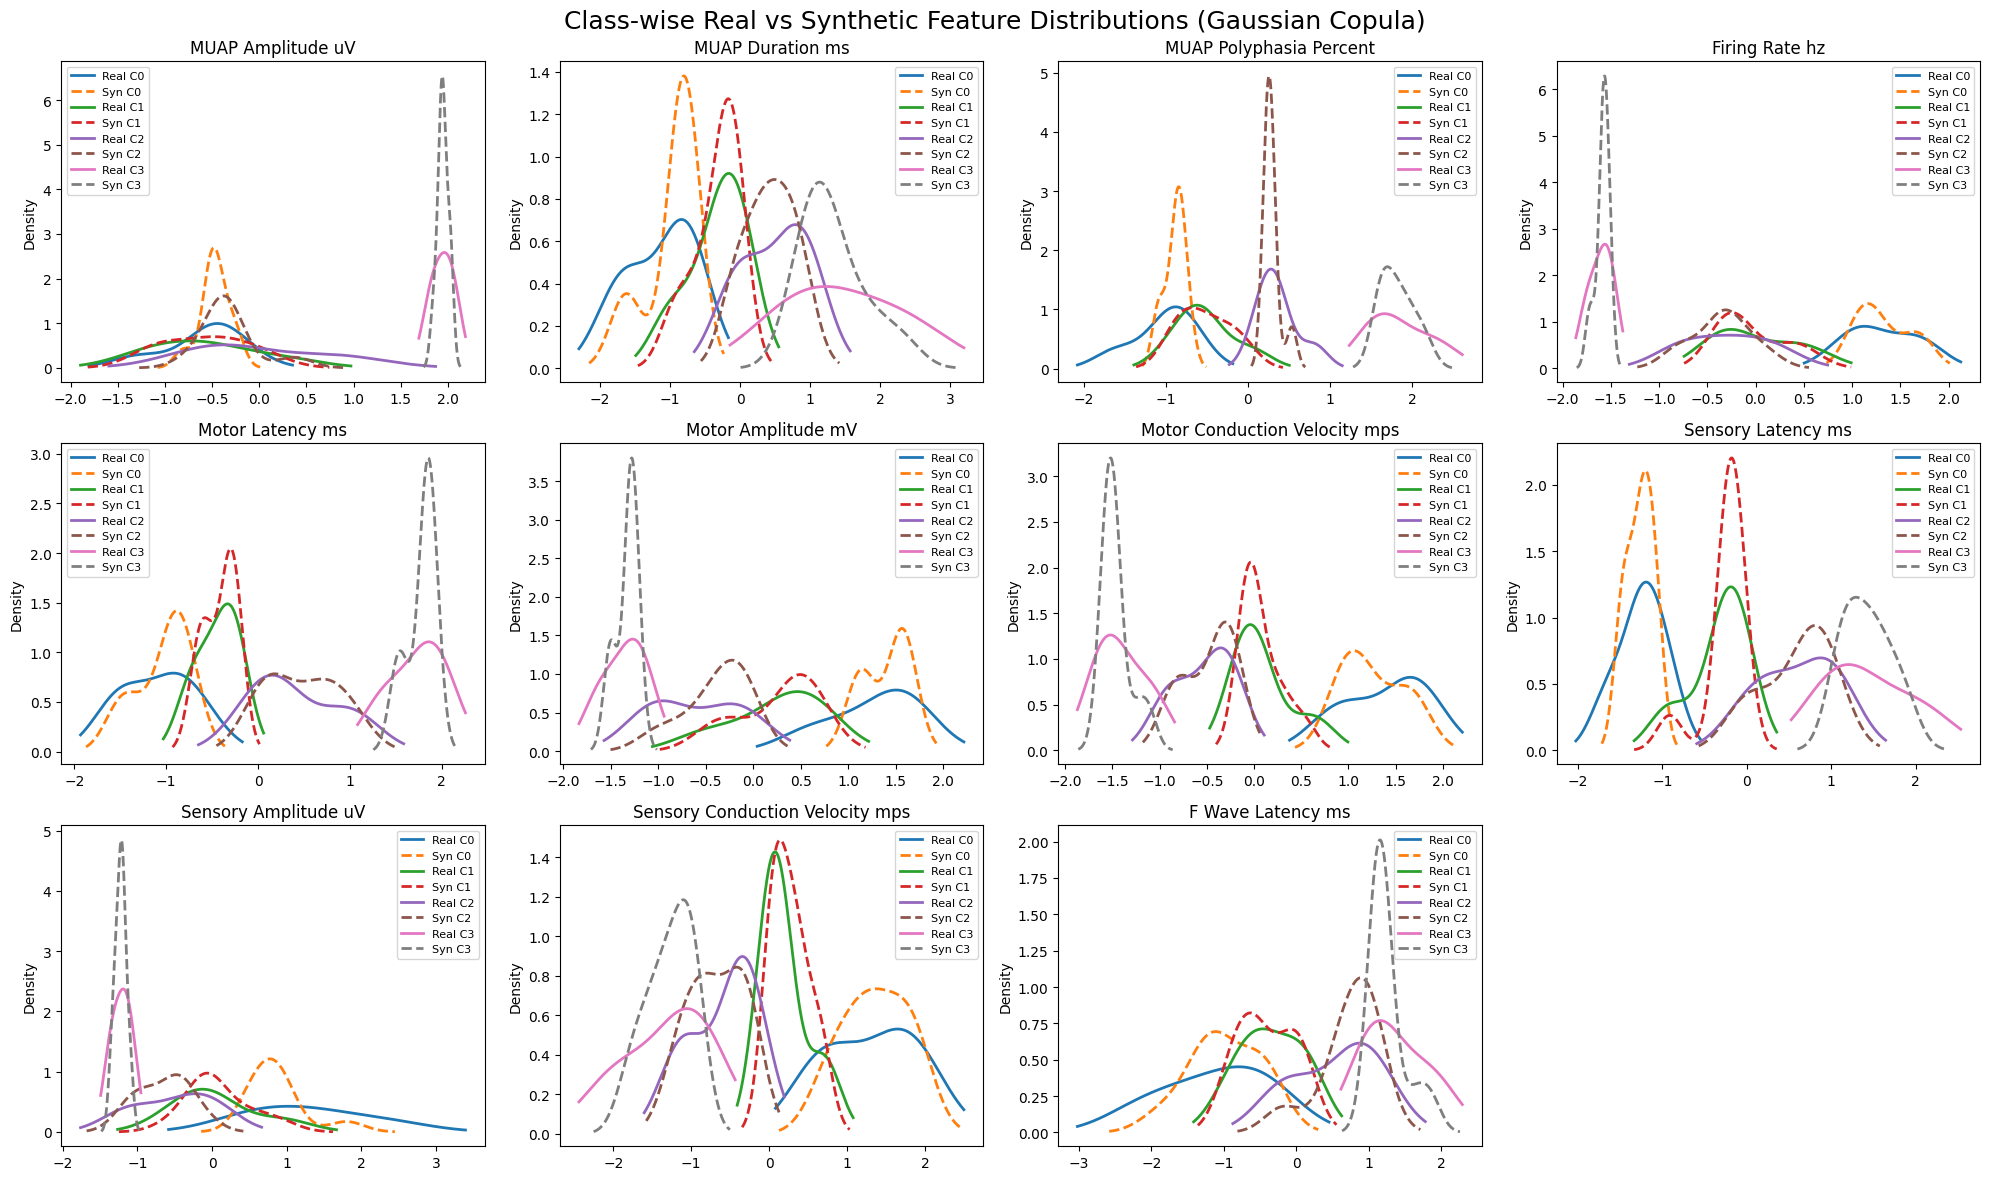

In [40]:
n_features = len(X_train_scaled.columns)

cols = 4
rows = math.ceil(n_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

fig.suptitle("Class-wise Real vs Synthetic Feature Distributions (Gaussian Copula)", fontsize=18)

for i, col in enumerate(X_train_scaled.columns):

    ax = axes[i]

    for cls in sorted(y_train.unique()):

        # Real values for this class
        real_values = X_train_scaled.loc[y_train == cls, col]

        # Synthetic values for this class
        syn_values = X_gc_syn_scaled.loc[y_gc_syn == cls, col]

        if len(real_values) > 1:
            real_values.plot(
                kind="kde",
                ax=ax,
                label=f"Real C{cls}",
                linewidth=2
            )

        if len(syn_values) > 1:
            syn_values.plot(
                kind="kde",
                ax=ax,
                linestyle="--",
                label=f"Syn C{cls}",
                linewidth=2
            )

    ax.set_title(col)
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Real vs Synthetic Histograms

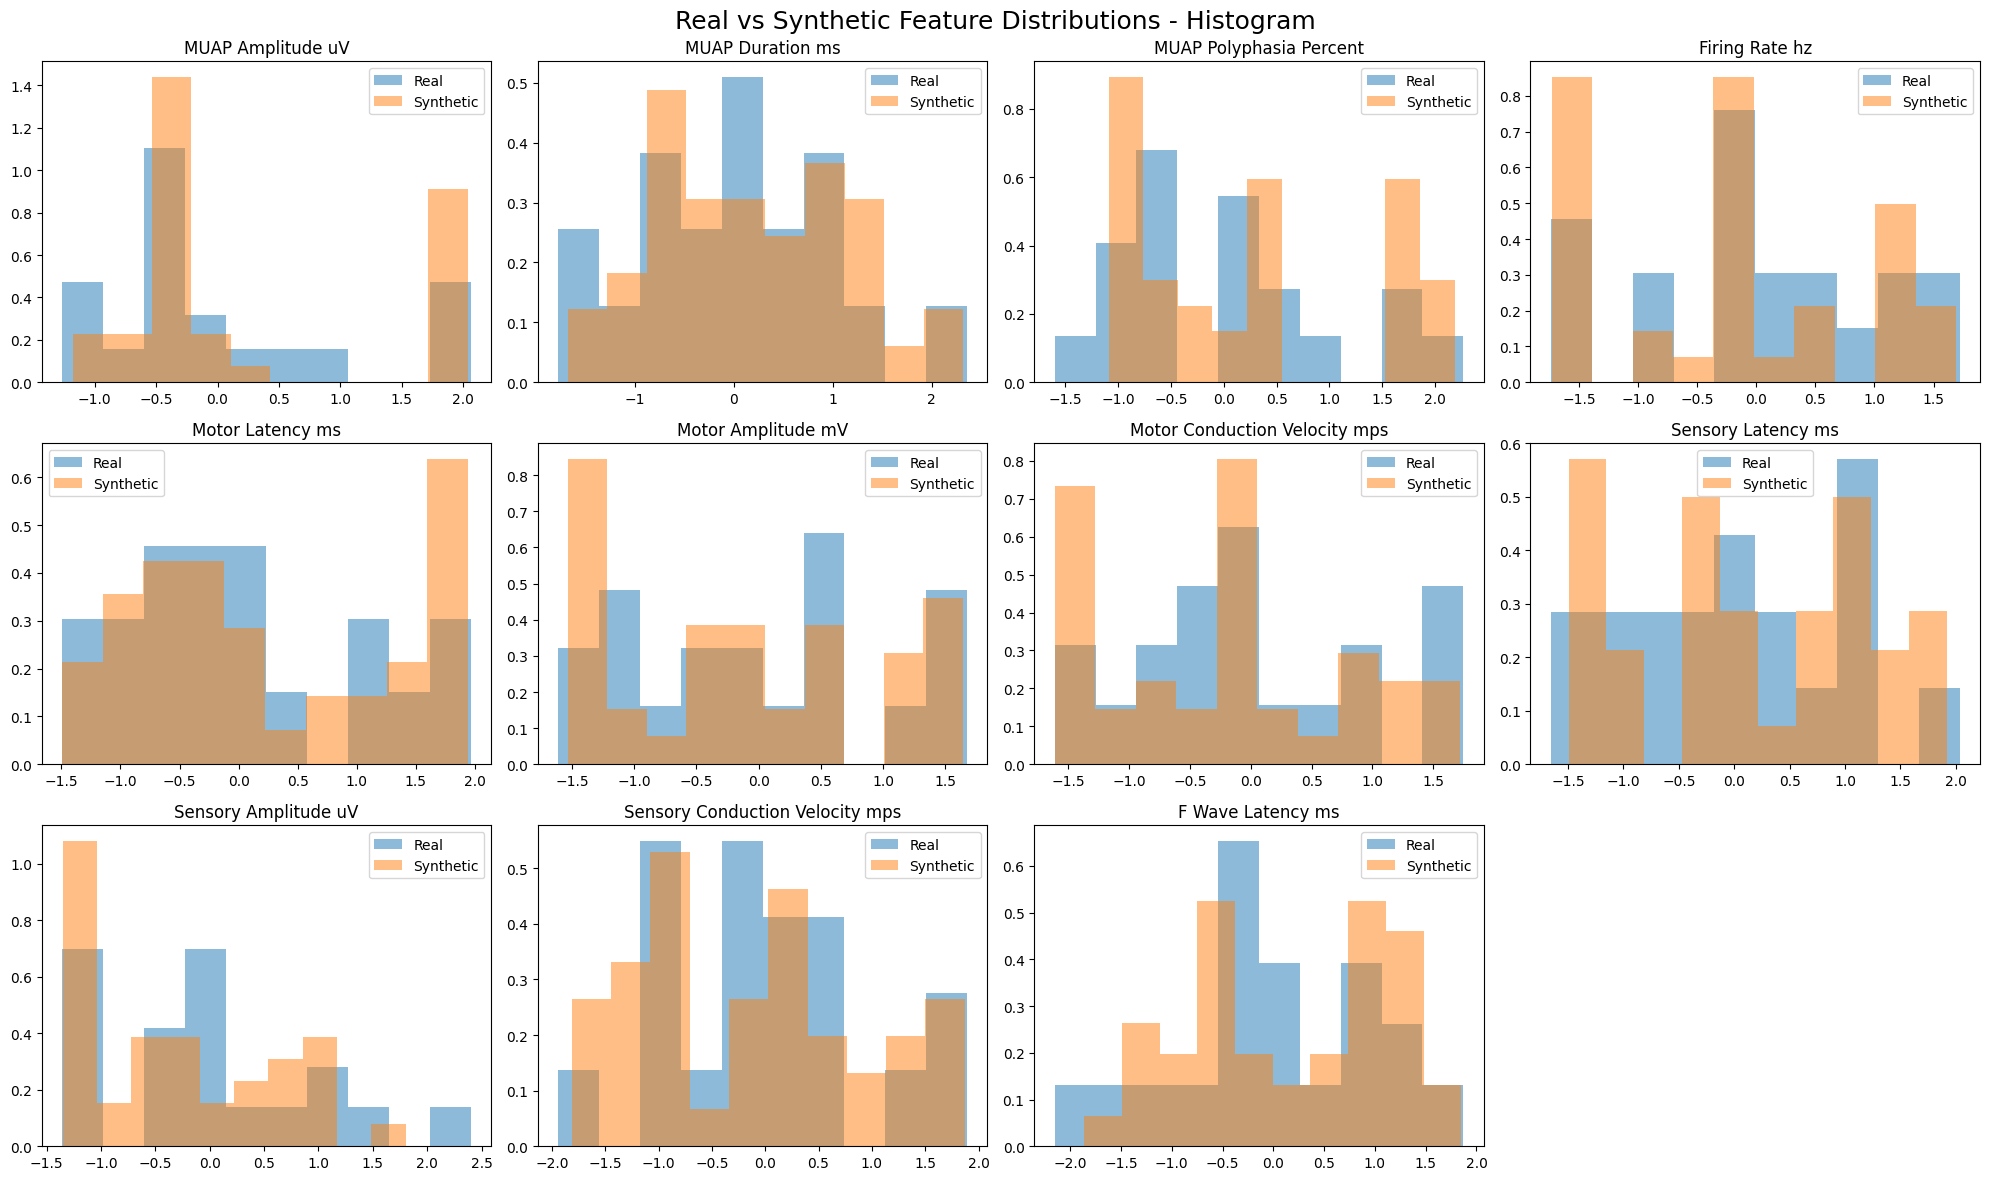

In [41]:
n_features = len(X_train_scaled.columns)

cols = 4
rows = math.ceil(n_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

fig.suptitle("Real vs Synthetic Feature Distributions - Histogram", fontsize=18)

for i, col in enumerate(X_train_scaled.columns):

    ax = axes[i]

    ax.hist(
        X_train_scaled[col],
        bins=10,
        alpha=0.5,
        label="Real",
        density=True
    )

    ax.hist(
        X_gc_syn_scaled[col],
        bins=10,
        alpha=0.5,
        label="Synthetic",
        density=True
    )

    ax.set_title(col)
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

---------------------------------------------

# ----------------------------------------------------------------------------------------------------------------------------------------------------------------

# Model Implemention

## SVM Cross-Validation Function

In [52]:
from sklearn.svm import SVC
from itertools import product

In [49]:
def run_svm_stratified_cv(X, y, experiment_name, model_params=None):

    X = X.copy()
    X.columns = X.columns.str.replace(' ', '_')

    class_names = ['Normal', 'Mild', 'Moderate', 'Severe']
    class_labels = [0, 1, 2, 3]

    severe_label = 3
    severe_index = class_labels.index(severe_label)

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    metrics_list = []
    fold_reports = []
    confusion_matrices = []

    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    # Default SVM parameters
    default_params = {
        'C': 1.0,
        'kernel': 'rbf',
        'gamma': 'scale',
        'class_weight': 'balanced',
        'probability': True,
        'random_state': 42
    }

    if model_params is not None:
        default_params.update(model_params)

    print("\n" + "=" * 100)
    print(f"Experiment: {experiment_name}")
    print("=" * 100)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):

        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]

        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        model = SVC(**default_params)
        model.fit(X_train_fold, y_train_fold)

        y_pred = model.predict(X_val_fold)
        y_proba = model.predict_proba(X_val_fold)

        all_y_true.extend(y_val_fold.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_y_proba.append(y_proba)

        acc = accuracy_score(y_val_fold, y_pred)
        precision_macro = precision_score(
            y_val_fold,
            y_pred,
            average='macro',
            zero_division=0
        )
        recall_macro = recall_score(
            y_val_fold,
            y_pred,
            average='macro',
            zero_division=0
        )
        f1_macro = f1_score(
            y_val_fold,
            y_pred,
            average='macro',
            zero_division=0
        )
        mcc = matthews_corrcoef(y_val_fold, y_pred)

        y_val_severe = (y_val_fold == severe_label).astype(int)
        y_proba_severe = y_proba[:, severe_index]
        ap_severe = average_precision_score(y_val_severe, y_proba_severe)

        metrics_list.append({
            'Fold': fold,
            'Accuracy': round(acc, 4),
            'Precision_macro': round(precision_macro, 4),
            'Recall_macro': round(recall_macro, 4),
            'F1_macro': round(f1_macro, 4),
            'MCC': round(mcc, 4),
            'AP_Severe': round(ap_severe, 4)
        })

        report_dict = classification_report(
            y_val_fold,
            y_pred,
            labels=class_labels,
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )

        report_df = pd.DataFrame(report_dict).transpose()
        report_df.insert(0, 'Fold', fold)
        fold_reports.append(report_df)

        cm = confusion_matrix(
            y_val_fold,
            y_pred,
            labels=class_labels
        )

        confusion_matrices.append(cm)

    summary_df = pd.DataFrame(metrics_list)

    print("\nFold-wise Metrics")
    display(summary_df)

    print("\nClassification Report for Each Fold")

    for i, report_df in enumerate(fold_reports, start=1):
        print(f"\nFold {i}")
        display(report_df.loc[class_names + ['accuracy', 'macro avg', 'weighted avg']])

    print("\nConfusion Matrices for Each Fold")

    for i, cm in enumerate(confusion_matrices, start=1):
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names
        )
        plt.title(f"{experiment_name} - Fold {i}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    all_y_proba = np.vstack(all_y_proba)

    agg_accuracy = accuracy_score(all_y_true, all_y_pred)
    agg_precision = precision_score(
        all_y_true,
        all_y_pred,
        average='macro',
        zero_division=0
    )
    agg_recall = recall_score(
        all_y_true,
        all_y_pred,
        average='macro',
        zero_division=0
    )
    agg_f1 = f1_score(
        all_y_true,
        all_y_pred,
        average='macro',
        zero_division=0
    )
    agg_mcc = matthews_corrcoef(all_y_true, all_y_pred)

    y_true_severe = (all_y_true == severe_label).astype(int)
    y_proba_severe_all = all_y_proba[:, severe_index]
    agg_ap_severe = average_precision_score(y_true_severe, y_proba_severe_all)

    aggregated_metrics_df = pd.DataFrame([{
        'Accuracy': round(agg_accuracy, 4),
        'Precision_macro': round(agg_precision, 4),
        'Recall_macro': round(agg_recall, 4),
        'F1_macro': round(agg_f1, 4),
        'MCC': round(agg_mcc, 4),
        'AP_Severe': round(agg_ap_severe, 4)
    }])

    print("\nAggregated Metrics Across All Folds")
    display(aggregated_metrics_df)

    aggregated_report_dict = classification_report(
        all_y_true,
        all_y_pred,
        labels=class_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    aggregated_report_df = pd.DataFrame(
        aggregated_report_dict
    ).transpose().round(4)

    print("\nAggregated Classification Report Across All Folds")
    display(aggregated_report_df.loc[class_names + ['accuracy', 'macro avg', 'weighted avg']])

    total_cm = np.sum(confusion_matrices, axis=0)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        total_cm,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"{experiment_name} - Aggregated Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    all_reports_df = pd.concat(fold_reports, axis=0)

    return summary_df, all_reports_df, aggregated_metrics_df, aggregated_report_df, total_cm

## Baseline SVM with Augmented Data


Experiment: SVM - Baseline with Gaussian Copula Augmented Data

Fold-wise Metrics


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,1.0,1.0,1.0,1.0,1.0,1.0
1,2,1.0,1.0,1.0,1.0,1.0,1.0
2,3,1.0,1.0,1.0,1.0,1.0,1.0
3,4,1.0,1.0,1.0,1.0,1.0,1.0
4,5,1.0,1.0,1.0,1.0,1.0,1.0



Classification Report for Each Fold

Fold 1


,Fold,precision,recall,f1-score,support
Normal,1,1.0,1.0,1.0,3.0
Mild,1,1.0,1.0,1.0,3.0
Moderate,1,1.0,1.0,1.0,3.0
Severe,1,1.0,1.0,1.0,3.0
accuracy,1,1.0,1.0,1.0,1.0
macro avg,1,1.0,1.0,1.0,12.0
weighted avg,1,1.0,1.0,1.0,12.0



Fold 2


...


Fold 4


,Fold,precision,recall,f1-score,support
Normal,4,1.0,1.0,1.0,3.0
Mild,4,1.0,1.0,1.0,3.0
Moderate,4,1.0,1.0,1.0,3.0
Severe,4,1.0,1.0,1.0,3.0
accuracy,4,1.0,1.0,1.0,1.0
macro avg,4,1.0,1.0,1.0,12.0
weighted avg,4,1.0,1.0,1.0,12.0



Fold 5


,Fold,precision,recall,f1-score,support
Normal,5,1.0,1.0,1.0,3.0
Mild,5,1.0,1.0,1.0,3.0
Moderate,5,1.0,1.0,1.0,3.0
Severe,5,1.0,1.0,1.0,3.0
accuracy,5,1.0,1.0,1.0,1.0
macro avg,5,1.0,1.0,1.0,12.0
weighted avg,5,1.0,1.0,1.0,12.0



Confusion Matrices for Each Fold


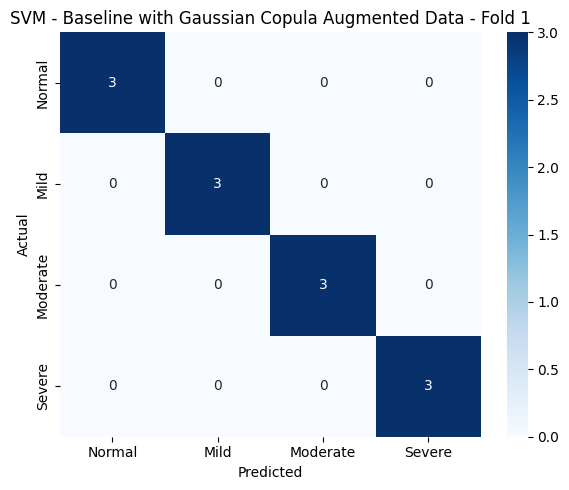

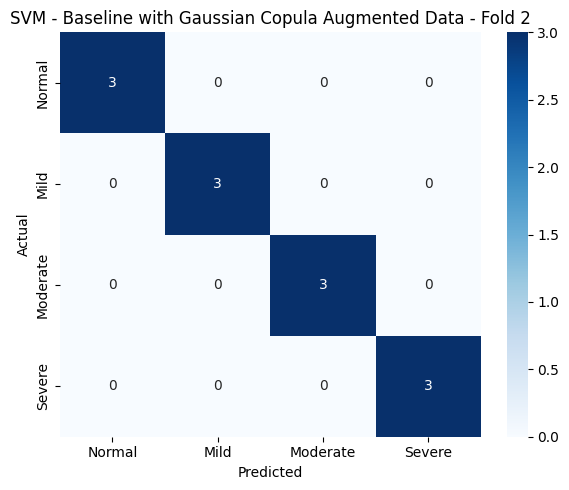

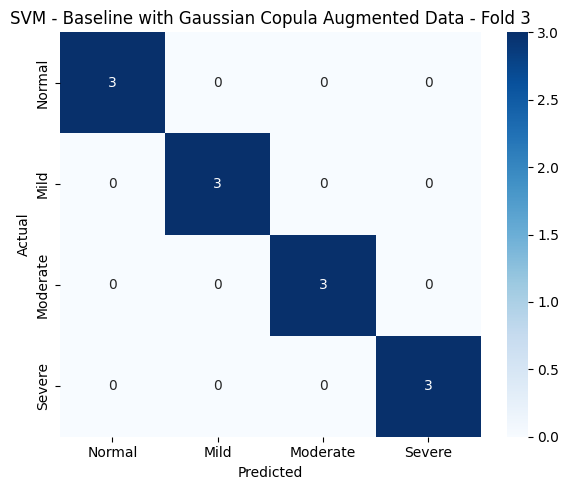

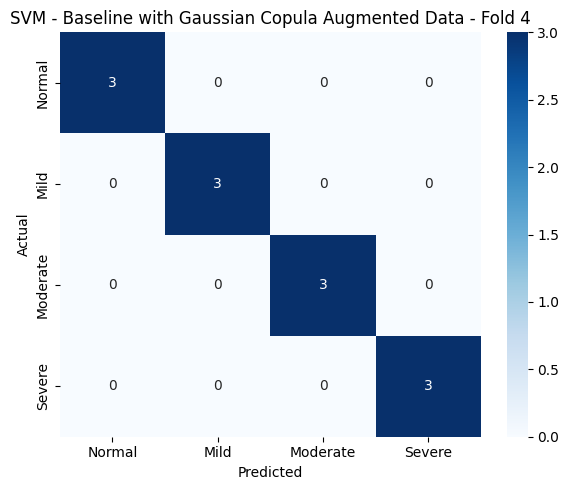

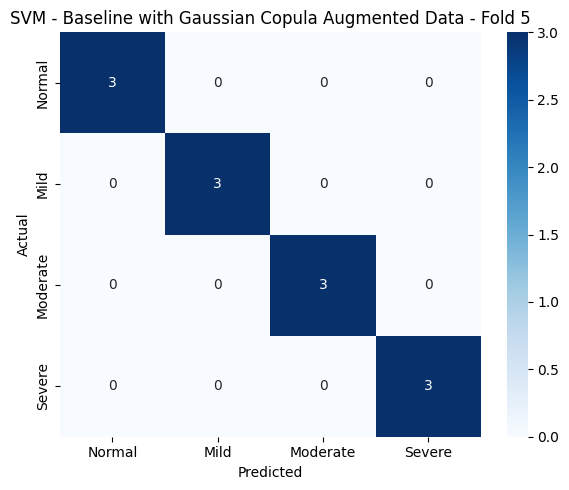


Aggregated Metrics Across All Folds


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1.0,1.0,1.0,1.0,1.0,1.0



Aggregated Classification Report Across All Folds


,precision,recall,f1-score,support
Normal,1.0,1.0,1.0,15.0
Mild,1.0,1.0,1.0,15.0
Moderate,1.0,1.0,1.0,15.0
Severe,1.0,1.0,1.0,15.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,60.0
weighted avg,1.0,1.0,1.0,60.0


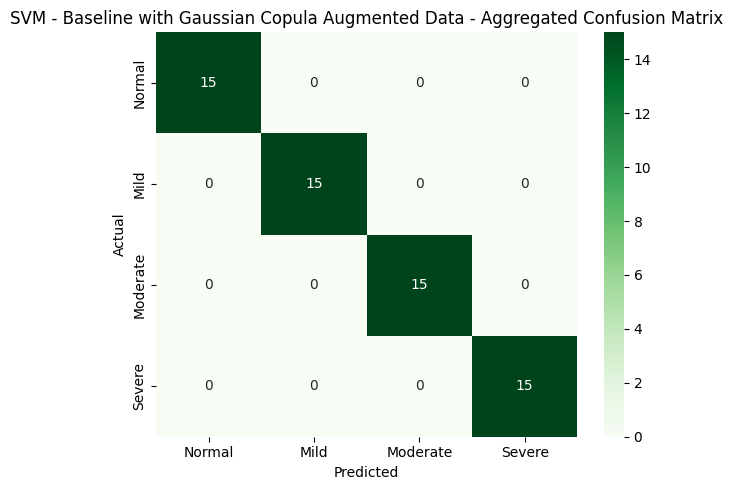

In [50]:
baseline_results, baseline_reports, baseline_agg_metrics, baseline_agg_report, baseline_cm = run_svm_stratified_cv(
    X=X_train_augmented,
    y=y_train_augmented,
    experiment_name='SVM - Baseline with Gaussian Copula Augmented Data'
)

# Hyperparameter Tuning

In [51]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 0.01, 0.001],
    'class_weight': ['balanced', None]
}

all_param_combinations = list(product(
    param_grid['C'],
    param_grid['kernel'],
    param_grid['gamma'],
    param_grid['class_weight']
))

print(f"Total combinations: {len(all_param_combinations)}")

Total combinations: 60


## Run Tuning with 5-Fold CV

In [53]:
X_used = X_train_augmented.copy()
X_used.columns = X_used.columns.str.replace(' ', '_')

y_used = y_train_augmented.copy()

class_labels = [0, 1, 2, 3]
severe_label = 3
severe_index = class_labels.index(severe_label)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

all_combo_results = []

for combo_id, (
    C,
    kernel,
    gamma,
    class_weight
) in enumerate(all_param_combinations, start=1):

    model_params = {
        'C': C,
        'kernel': kernel,
        'gamma': gamma,
        'class_weight': class_weight,
        'probability': True,
        'random_state': 42
    }

    combo_fold_results = []

    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_used, y_used), start=1):

        X_train_fold = X_used.iloc[train_idx]
        X_val_fold = X_used.iloc[val_idx]

        y_train_fold = y_used.iloc[train_idx]
        y_val_fold = y_used.iloc[val_idx]

        model = SVC(**model_params)

        model.fit(X_train_fold, y_train_fold)

        y_pred = model.predict(X_val_fold)
        y_proba = model.predict_proba(X_val_fold)

        all_y_true.extend(y_val_fold.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_y_proba.append(y_proba)

        acc = accuracy_score(y_val_fold, y_pred)

        precision_macro = precision_score(
            y_val_fold,
            y_pred,
            average='macro',
            zero_division=0
        )

        recall_macro = recall_score(
            y_val_fold,
            y_pred,
            average='macro',
            zero_division=0
        )

        f1_macro = f1_score(
            y_val_fold,
            y_pred,
            average='macro',
            zero_division=0
        )

        mcc = matthews_corrcoef(y_val_fold, y_pred)

        y_val_severe = (y_val_fold == severe_label).astype(int)
        y_proba_severe = y_proba[:, severe_index]

        ap_severe = average_precision_score(
            y_val_severe,
            y_proba_severe
        )

        combo_fold_results.append({
            'Fold': fold,
            'Accuracy': round(acc, 4),
            'Precision_macro': round(precision_macro, 4),
            'Recall_macro': round(recall_macro, 4),
            'F1_macro': round(f1_macro, 4),
            'MCC': round(mcc, 4),
            'AP_Severe': round(ap_severe, 4)
        })

    combo_fold_df = pd.DataFrame(combo_fold_results)

    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    all_y_proba = np.vstack(all_y_proba)

    agg_accuracy = accuracy_score(all_y_true, all_y_pred)

    agg_precision = precision_score(
        all_y_true,
        all_y_pred,
        average='macro',
        zero_division=0
    )

    agg_recall = recall_score(
        all_y_true,
        all_y_pred,
        average='macro',
        zero_division=0
    )

    agg_f1 = f1_score(
        all_y_true,
        all_y_pred,
        average='macro',
        zero_division=0
    )

    agg_mcc = matthews_corrcoef(all_y_true, all_y_pred)

    y_true_severe = (all_y_true == severe_label).astype(int)
    y_proba_severe_all = all_y_proba[:, severe_index]

    agg_ap_severe = average_precision_score(
        y_true_severe,
        y_proba_severe_all
    )

    combo_summary = {
        'Combo_ID': combo_id,
        'C': C,
        'kernel': kernel,
        'gamma': gamma,
        'class_weight': class_weight,

        'Accuracy_Mean': round(combo_fold_df['Accuracy'].mean(), 4),
        'Precision_Mean': round(combo_fold_df['Precision_macro'].mean(), 4),
        'Recall_Mean': round(combo_fold_df['Recall_macro'].mean(), 4),
        'F1_Mean': round(combo_fold_df['F1_macro'].mean(), 4),
        'MCC_Mean': round(combo_fold_df['MCC'].mean(), 4),
        'AP_Severe_Mean': round(combo_fold_df['AP_Severe'].mean(), 4),

        'Accuracy_Agg': round(agg_accuracy, 4),
        'Precision_Agg': round(agg_precision, 4),
        'Recall_Agg': round(agg_recall, 4),
        'F1_Agg': round(agg_f1, 4),
        'MCC_Agg': round(agg_mcc, 4),
        'AP_Severe_Agg': round(agg_ap_severe, 4)
    }

    all_combo_results.append(combo_summary)

    print(
        f"[{combo_id:03}/{len(all_param_combinations)}] "
        f"C={C} | kernel={kernel} | gamma={gamma} | class_weight={class_weight} | "
        f"F1_Mean={combo_summary['F1_Mean']:.4f} | "
        f"MCC_Mean={combo_summary['MCC_Mean']:.4f} | "
        f"AP_Severe_Mean={combo_summary['AP_Severe_Mean']:.4f}"
    )

[001/60] C=0.01 | kernel=rbf | gamma=scale | class_weight=balanced | F1_Mean=1.0000 | MCC_Mean=1.0000 | AP_Severe_Mean=0.1773
[002/60] C=0.01 | kernel=rbf | gamma=scale | class_weight=None | F1_Mean=1.0000 | MCC_Mean=1.0000 | AP_Severe_Mean=0.1773
[003/60] C=0.01 | kernel=rbf | gamma=0.01 | class_weight=balanced | F1_Mean=1.0000 | MCC_Mean=1.0000 | AP_Severe_Mean=0.1773
[004/60] C=0.01 | kernel=rbf | gamma=0.01 | class_weight=None | F1_Mean=1.0000 | MCC_Mean=1.0000 | AP_Severe_Mean=0.1773
[005/60] C=0.01 | kernel=rbf | gamma=0.001 | class_weight=balanced | F1_Mean=1.0000 | MCC_Mean=1.0000 | AP_Severe_Mean=0.1773
[006/60] C=0.01 | kernel=rbf | gamma=0.001 | class_weight=None | F1_Mean=1.0000 | MCC_Mean=1.0000 | AP_Severe_Mean=0.1773
[007/60] C=0.01 | kernel=linear | gamma=scale | class_weight=balanced | F1_Mean=1.0000 | MCC_Mean=1.0000 | AP_Severe_Mean=1.0000
[008/60] C=0.01 | kernel=linear | gamma=scale | class_weight=None | F1_Mean=1.0000 | MCC_Mean=1.0000 | AP_Severe_Mean=1.0000
[009

## Rank Tuning Results

In [54]:
all_combo_results_df = pd.DataFrame(all_combo_results)

ranked_results_df = all_combo_results_df.sort_values(
    by='F1_Mean',
    ascending=False
).reset_index(drop=True)

display(ranked_results_df.head(10))

,Combo_ID,C,kernel,gamma,class_weight,Accuracy_Mean,Precision_Mean,Recall_Mean,F1_Mean,MCC_Mean,AP_Severe_Mean,Accuracy_Agg,Precision_Agg,Recall_Agg,F1_Agg,MCC_Agg,AP_Severe_Agg
0,1,0.01,rbf,scale,balanced,1.0,1.0,1.0,1.0,1.0,0.1773,1.0,1.0,1.0,1.0,1.0,0.1452
1,2,0.01,rbf,scale,None,1.0,1.0,1.0,1.0,1.0,0.1773,1.0,1.0,1.0,1.0,1.0,0.1452
2,3,0.01,rbf,0.01,balanced,1.0,1.0,1.0,1.0,1.0,0.1773,1.0,1.0,1.0,1.0,1.0,0.1452
3,4,0.01,rbf,0.01,None,1.0,1.0,1.0,1.0,1.0,0.1773,1.0,1.0,1.0,1.0,1.0,0.1452
4,5,0.01,rbf,0.001,balanced,1.0,1.0,1.0,1.0,1.0,0.1773,1.0,1.0,1.0,1.0,1.0,0.1452
5,6,0.01,rbf,0.001,None,1.0,1.0,1.0,1.0,1.0,0.1773,1.0,1.0,1.0,1.0,1.0,0.1452
6,7,0.01,linear,scale,balanced,1.0,1.0,1.0,1.0,1.0,1.0000,1.0,1.0,1.0,1.0,1.0,1.0000
7,8,0.01,linear,scale,None,1.0,1.0,1.0,1.0,1.0,1.0000,1.0,1.0,1.0,1.0,1.0,1.0000
8,9,0.01,linear,0.01,balanced,1.0,1.0,1.0,1.0,1.0,1.0000,1.0,1.0,1.0,1.0,1.0,1.0000
9,10,0.01,linear,0.01,None,1.0,1.0,1.0,1.0,1.0,1.0000,1.0,1.0,1.0,1.0,1.0,1.0000


## Best Hyperparameter Combination

In [55]:
best_combo_row = ranked_results_df.iloc[0]

print("Best hyperparameter combination:")
print(f"Combo_ID: {best_combo_row['Combo_ID']}")
print(f"C: {best_combo_row['C']}")
print(f"kernel: {best_combo_row['kernel']}")
print(f"gamma: {best_combo_row['gamma']}")
print(f"class_weight: {best_combo_row['class_weight']}")

print("-" * 100)
print(f"F1_Mean: {best_combo_row['F1_Mean']}")
print(f"F1_Agg: {best_combo_row['F1_Agg']}")
print(f"MCC_Mean: {best_combo_row['MCC_Mean']}")
print(f"MCC_Agg: {best_combo_row['MCC_Agg']}")
print(f"AP_Severe_Mean: {best_combo_row['AP_Severe_Mean']}")
print(f"AP_Severe_Agg: {best_combo_row['AP_Severe_Agg']}")

Best hyperparameter combination:
Combo_ID: 1
C: 0.01
kernel: rbf
gamma: scale
class_weight: balanced
----------------------------------------------------------------------------------------------------
F1_Mean: 1.0
F1_Agg: 1.0
MCC_Mean: 1.0
MCC_Agg: 1.0
AP_Severe_Mean: 0.1773
AP_Severe_Agg: 0.1452


## Prepare Best Model Parameters

In [56]:
best_model_params = {
    'C': best_combo_row['C'],
    'kernel': best_combo_row['kernel'],
    'gamma': best_combo_row['gamma'],
    'class_weight': best_combo_row['class_weight'],
    'probability': True,
    'random_state': 42
}

best_model_params

{'C': np.float64(0.01),
 'kernel': 'rbf',
 'gamma': 'scale',
 'class_weight': 'balanced',
 'probability': True,
 'random_state': 42}

## Cross-Validation Using Best Parameters


Experiment: Tuned SVM - Gaussian Copula Augmented Data

Fold-wise Metrics


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,1.0,1.0,1.0,1.0,1.0,0.1773
1,2,1.0,1.0,1.0,1.0,1.0,0.1773
2,3,1.0,1.0,1.0,1.0,1.0,0.1773
3,4,1.0,1.0,1.0,1.0,1.0,0.1773
4,5,1.0,1.0,1.0,1.0,1.0,0.1773



Classification Report for Each Fold

Fold 1


,Fold,precision,recall,f1-score,support
Normal,1,1.0,1.0,1.0,3.0
Mild,1,1.0,1.0,1.0,3.0
Moderate,1,1.0,1.0,1.0,3.0
Severe,1,1.0,1.0,1.0,3.0
accuracy,1,1.0,1.0,1.0,1.0
macro avg,1,1.0,1.0,1.0,12.0
weighted avg,1,1.0,1.0,1.0,12.0



Fold 2


...


Fold 4


,Fold,precision,recall,f1-score,support
Normal,4,1.0,1.0,1.0,3.0
Mild,4,1.0,1.0,1.0,3.0
Moderate,4,1.0,1.0,1.0,3.0
Severe,4,1.0,1.0,1.0,3.0
accuracy,4,1.0,1.0,1.0,1.0
macro avg,4,1.0,1.0,1.0,12.0
weighted avg,4,1.0,1.0,1.0,12.0



Fold 5


,Fold,precision,recall,f1-score,support
Normal,5,1.0,1.0,1.0,3.0
Mild,5,1.0,1.0,1.0,3.0
Moderate,5,1.0,1.0,1.0,3.0
Severe,5,1.0,1.0,1.0,3.0
accuracy,5,1.0,1.0,1.0,1.0
macro avg,5,1.0,1.0,1.0,12.0
weighted avg,5,1.0,1.0,1.0,12.0



Confusion Matrices for Each Fold


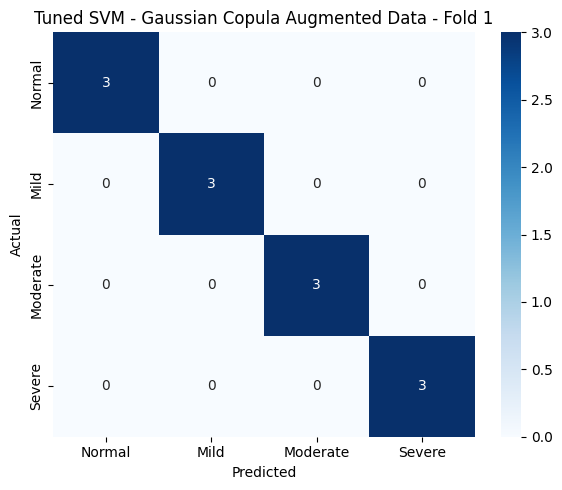

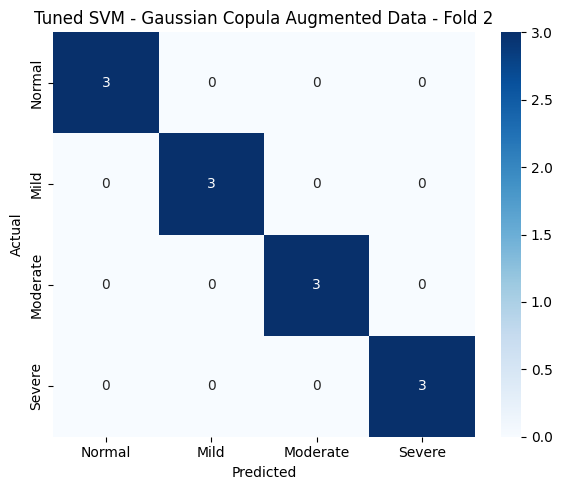

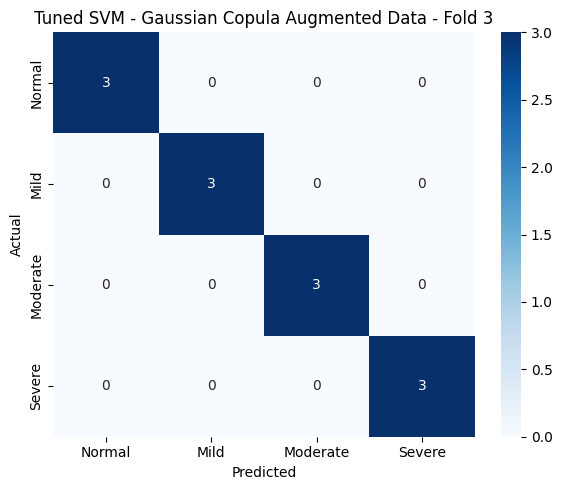

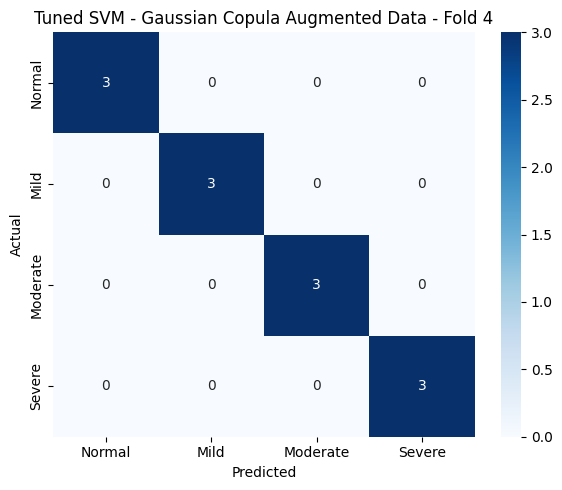

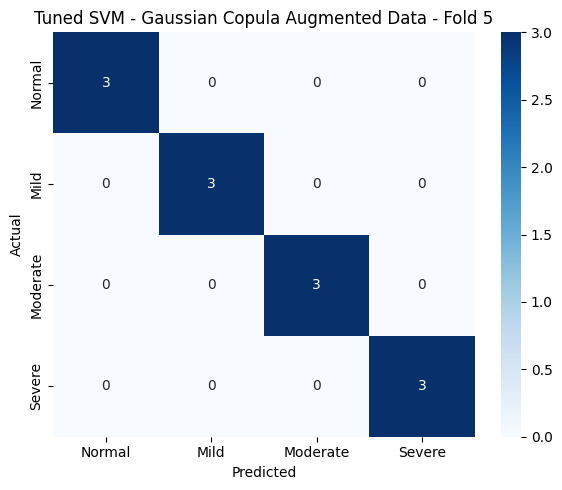


Aggregated Metrics Across All Folds


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1.0,1.0,1.0,1.0,1.0,0.1452



Aggregated Classification Report Across All Folds


,precision,recall,f1-score,support
Normal,1.0,1.0,1.0,15.0
Mild,1.0,1.0,1.0,15.0
Moderate,1.0,1.0,1.0,15.0
Severe,1.0,1.0,1.0,15.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,60.0
weighted avg,1.0,1.0,1.0,60.0


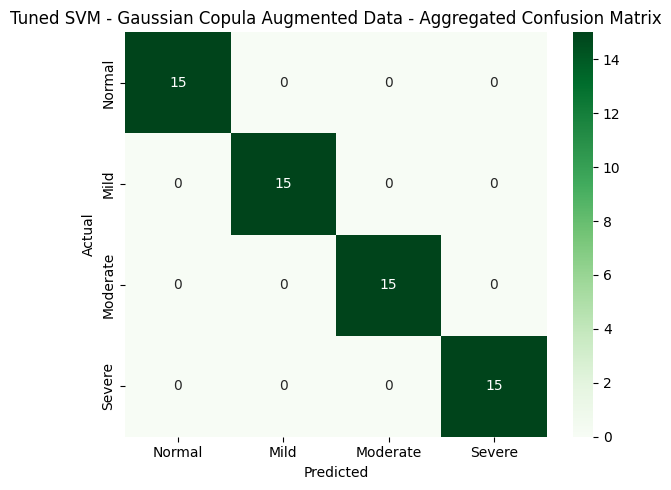

In [57]:
tuned_results, tuned_reports, tuned_agg_metrics, tuned_agg_report, tuned_cm = run_svm_stratified_cv(
    X=X_train_augmented,
    y=y_train_augmented,
    experiment_name='Tuned SVM - Gaussian Copula Augmented Data',
    model_params=best_model_params
)

# Train Final Model

In [58]:
X_train_final = X_train_augmented.copy()
X_test_final = X_test_scaled.copy()

X_train_final.columns = X_train_final.columns.str.replace(' ', '_')
X_test_final.columns = X_test_final.columns.str.replace(' ', '_')

print("Final training shape:", X_train_final.shape)
print("Final testing shape :", X_test_final.shape)

final_svm_model = SVC(
    **best_model_params
)

final_svm_model.fit(X_train_final, y_train_augmented)

print("Final SVM model has been trained.")

Final training shape: (60, 11)
Final testing shape : (9, 11)
Final SVM model has been trained.


# Test Set Evaluation

In [59]:
class_names = ['Normal', 'Mild', 'Moderate', 'Severe']
class_labels = [0, 1, 2, 3]

severe_label = 3
severe_index = class_labels.index(severe_label)

y_test_pred = final_svm_model.predict(X_test_final)
y_test_proba = final_svm_model.predict_proba(X_test_final)

test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision_macro = precision_score(
    y_test,
    y_test_pred,
    average='macro',
    zero_division=0
)

test_recall_macro = recall_score(
    y_test,
    y_test_pred,
    average='macro',
    zero_division=0
)

test_f1_macro = f1_score(
    y_test,
    y_test_pred,
    average='macro',
    zero_division=0
)

test_mcc = matthews_corrcoef(y_test, y_test_pred)

y_test_severe = (y_test == severe_label).astype(int)
y_test_proba_severe = y_test_proba[:, severe_index]

test_ap_severe = average_precision_score(
    y_test_severe,
    y_test_proba_severe
)

test_metrics_df = pd.DataFrame([{
    'Accuracy': round(test_accuracy, 4),
    'Precision_macro': round(test_precision_macro, 4),
    'Recall_macro': round(test_recall_macro, 4),
    'F1_macro': round(test_f1_macro, 4),
    'MCC': round(test_mcc, 4),
    'AP_Severe': round(test_ap_severe, 4)
}])

print("Final SVM - Test Set Metrics")
display(test_metrics_df)

Final SVM - Test Set Metrics


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1.0,1.0,1.0,1.0,1.0,0.1736


## Test Classification Report

In [60]:
test_report_dict = classification_report(
    y_test,
    y_test_pred,
    labels=class_labels,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

test_report_df = pd.DataFrame(test_report_dict).transpose().round(4)

display(test_report_df.loc[class_names + ['accuracy', 'macro avg', 'weighted avg']])

,precision,recall,f1-score,support
Normal,1.0,1.0,1.0,3.0
Mild,1.0,1.0,1.0,2.0
Moderate,1.0,1.0,1.0,2.0
Severe,1.0,1.0,1.0,2.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,9.0
weighted avg,1.0,1.0,1.0,9.0


## Test Confusion Matrix

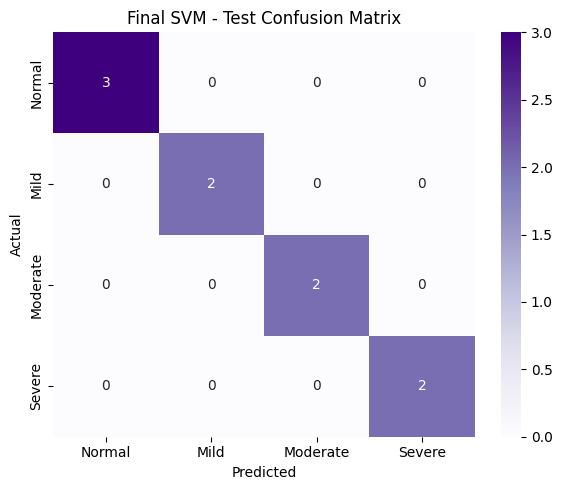

In [61]:
test_cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=class_labels
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Final SVM - Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

#Overfitting Check

In [62]:
best_cv_accuracy = tuned_agg_metrics.loc[0, 'Accuracy']
best_cv_precision_macro = tuned_agg_metrics.loc[0, 'Precision_macro']
best_cv_recall_macro = tuned_agg_metrics.loc[0, 'Recall_macro']
best_cv_f1_macro = tuned_agg_metrics.loc[0, 'F1_macro']
best_cv_mcc = tuned_agg_metrics.loc[0, 'MCC']
best_cv_ap_severe = tuned_agg_metrics.loc[0, 'AP_Severe']

cv_vs_test_df = pd.DataFrame([
    ['Train Set', best_cv_accuracy, best_cv_precision_macro, best_cv_recall_macro, best_cv_f1_macro, best_cv_mcc, best_cv_ap_severe],
    ['Test Set',  test_accuracy,    test_precision_macro,    test_recall_macro,    test_f1_macro,    test_mcc,    test_ap_severe]
], columns=['Dataset', 'Accuracy', 'Precision_macro', 'Recall_macro', 'F1_macro', 'MCC', 'AP_Severe'])

cv_vs_test_df.iloc[:, 1:] = cv_vs_test_df.iloc[:, 1:].round(4)

print("Train Set vs Test Set")
display(cv_vs_test_df)

Train Set vs Test Set


,Dataset,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,Train Set,1.0,1.0,1.0,1.0,1.0,0.1452
1,Test Set,1.0,1.0,1.0,1.0,1.0,0.1736


In [63]:
cv_test_gap_df = pd.DataFrame([{
    'Accuracy_Gap': round(best_cv_accuracy - test_accuracy, 4),
    'Precision_macro_Gap': round(best_cv_precision_macro - test_precision_macro, 4),
    'Recall_macro_Gap': round(best_cv_recall_macro - test_recall_macro, 4),
    'F1_macro_Gap': round(best_cv_f1_macro - test_f1_macro, 4),
    'MCC_Gap': round(best_cv_mcc - test_mcc, 4),
    'AP_Severe_Gap': round(best_cv_ap_severe - test_ap_severe, 4)
}])

print("Overfitting Check (Train - Test)")
display(cv_test_gap_df)

Overfitting Check (Train - Test)


,Accuracy_Gap,Precision_macro_Gap,Recall_macro_Gap,F1_macro_Gap,MCC_Gap,AP_Severe_Gap
0,0.0,0.0,0.0,0.0,0.0,-0.0284


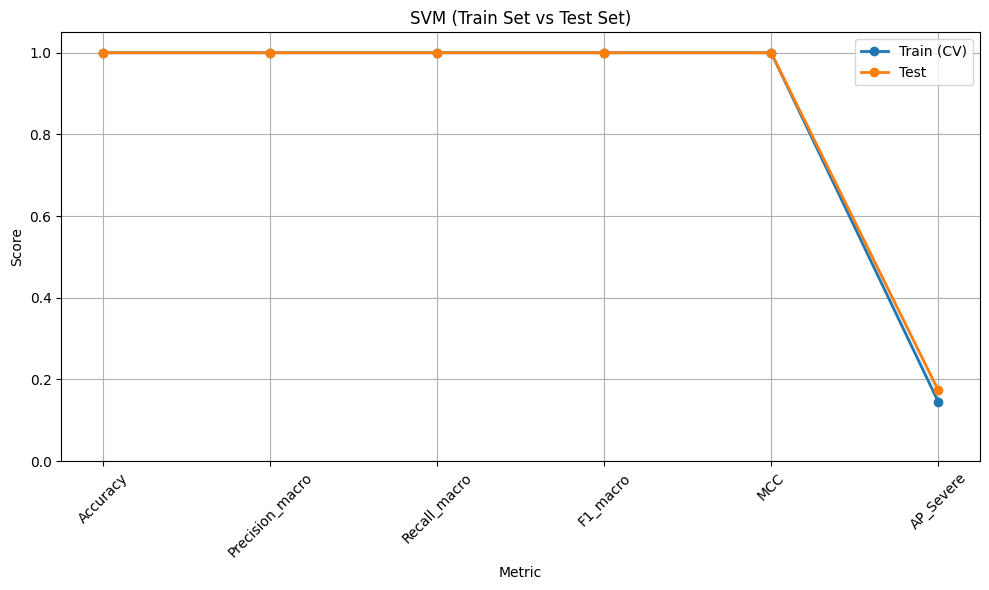

In [64]:
plot_df = cv_vs_test_df.set_index('Dataset').T

plt.figure(figsize=(10, 6))
plt.plot(plot_df.index, plot_df['Train Set'], marker='o', linewidth=2, label='Train (CV)')
plt.plot(plot_df.index, plot_df['Test Set'], marker='o', linewidth=2, label='Test')
plt.fill_between(plot_df.index, plot_df['Train Set'], plot_df['Test Set'], alpha=0.1)

plt.title("SVM (Train Set vs Test Set)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(rotation=45)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [65]:
label_names = {
    0: 'Normal',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe'
}

sample_predictions_named = pd.DataFrame({
    'Actual': y_test.map(label_names).values,
    'Predicted': pd.Series(y_test_pred, index=y_test.index).map(label_names).values
}, index=y_test.index)

print("Sample Predictions with Class Names")
display(sample_predictions_named.head(10))

proba_df = pd.DataFrame(
    y_test_proba,
    columns=['Prob_Normal', 'Prob_Mild', 'Prob_Moderate', 'Prob_Severe'],
    index=y_test.index
)

prediction_with_proba = pd.concat([sample_predictions_named, proba_df], axis=1)

print("Sample Predictions with Probabilities")
display(prediction_with_proba.head(10))

errors_df = prediction_with_proba[
    prediction_with_proba['Actual'] != prediction_with_proba['Predicted']
]

print("Misclassified Samples")
display(errors_df.head(10))

Sample Predictions with Class Names


,Actual,Predicted
7,Mild,Mild
18,Normal,Normal
14,Severe,Severe
12,Moderate,Moderate
15,Normal,Normal
23,Mild,Mild
21,Normal,Normal
27,Moderate,Moderate
10,Severe,Severe


Sample Predictions with Probabilities


,Actual,Predicted,Prob_Normal,Prob_Mild,Prob_Moderate,Prob_Severe
7,Mild,Mild,0.247813,0.244081,0.250815,0.257291
18,Normal,Normal,0.243808,0.249412,0.252738,0.254042
14,Severe,Severe,0.254224,0.253940,0.248971,0.242864
12,Moderate,Moderate,0.254912,0.247031,0.243246,0.254810
15,Normal,Normal,0.242946,0.249389,0.253090,0.254575
23,Mild,Mild,0.247979,0.242955,0.251683,0.257383
21,Normal,Normal,0.242941,0.249358,0.253054,0.254647
27,Moderate,Moderate,0.256317,0.249004,0.241604,0.253074
10,Severe,Severe,0.254784,0.253980,0.248169,0.243067


Misclassified Samples


,Actual,Predicted,Prob_Normal,Prob_Mild,Prob_Moderate,Prob_Severe


# Train on Full Dataset + Save Deployment Model

In [68]:
X_full_selected = pd.concat([
    X_train_augmented,   # already scaled
    X_test_scaled        # already scaled
], axis=0)

y_full = pd.concat([y_train_augmented, y_test], axis=0)

X_full_selected = X_full_selected.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

print("Full dataset shape :", X_full_selected.shape)
print("Full target shape  :", y_full.shape)
print("Selected features  :", selected_features)

X_full_selected.columns = X_full_selected.columns.str.replace(' ', '_')

final_deployment_svm_model = SVC(
    **best_model_params
)

final_deployment_svm_model.fit(X_full_selected, y_full)

print("Final deployment SVM model has been trained on the full scaled dataset.")

Full dataset shape : (69, 11)
Full target shape  : (69,)
Selected features  : ['MUAP Amplitude uV', 'MUAP Duration ms', 'MUAP Polyphasia Percent', 'Firing Rate hz', 'Motor Latency ms', 'Motor Amplitude mV', 'Motor Conduction Velocity mps', 'Sensory Latency ms', 'Sensory Amplitude uV', 'Sensory Conduction Velocity mps', 'F Wave Latency ms']
Final deployment SVM model has been trained on the full scaled dataset.


In [69]:
# Save model
joblib.dump(final_deployment_svm_model, 'integrated_svm_model.pkl')

# Save features
joblib.dump(selected_features, 'integrated_svm_selected_features.pkl')

# Save scaler
joblib.dump(scaler, 'integrated_scaler.pkl')

print("Model + features + scaler saved successfully")

Model + features + scaler saved successfully
